In [1]:
import pandas
import numpy as numpy
import seaborn as seaborn
import matplotlib.pyplot as pyplot
from sklearn import preprocessing
from datetime import datetime
import re
from collections import defaultdict
import copy
    
def build_heatmap(correlation_data, graph_title: str):
    pyplot.figure(figsize=(7, 5))
    seaborn.heatmap(correlation_data, annot=True, cmap='seismic', center=0)
    pyplot.title(graph_title)
    pyplot.show()
    
def build_parameter_distribution_graph(data, columns: int, rows: int):
    fig, axs = pyplot.subplots(ncols=columns, nrows=rows, figsize=(20, 10))
    index = 0
    axs = axs.flatten()
    for k,v in data.items():
        seaborn.histplot(v, ax=axs[index])
        index += 1
    pyplot.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
    
def build_dot_distribution(data, column_names: list[str], y_name: str, columns: int, rows: int):
    min_max_scaler = preprocessing.MinMaxScaler()
    x = data.loc[:,column_names]
    y = data[y_name]
    x = pandas.DataFrame(data=min_max_scaler.fit_transform(x), columns=column_names)
    fig, axs = pyplot.subplots(ncols=columns, nrows=rows, figsize=(20, 10))
    index = 0
    axs = axs.flatten()
    for i, k in enumerate(column_names):
        seaborn.regplot(y=y, x=x[k], ax=axs[i])
    pyplot.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)

def build_survived_comparison_per_parameter(data, columns: int, rows: int):
    categorical_columns = data.columns.tolist()
    categorical_columns.remove('AgeGroup')
    categorical_columns.remove('FareGroup')
        
    fig, axs = pyplot.subplots(ncols=columns, nrows=rows, figsize=(10, 20))
    index = 0
    axs = axs.flatten()
    for index, col in enumerate(categorical_columns):
        if col == 'Age':
            seaborn.countplot(data=data, x='AgeGroup', hue='Survived', ax=axs[index])
        elif col == 'Fare':
            seaborn.countplot(data=data, x='FareGroup', hue='Survived', ax=axs[index])
            axs[index].tick_params(axis='x', rotation=45)
        else:
            seaborn.countplot(data=data, x=col, hue='Survived', ax=axs[index])
            
        axs[index].set_title(f'Distribution of {col} split by Survived')
        pyplot.xlabel(axs[index])
        pyplot.ylabel('Count')
        axs[index].legend(title='Survived')
        index += 1
    pyplot.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)

def build_pie_chart_for_parameters(data, parameter_names: list[str], columns: int, rows: int):
    fig, axs = pyplot.subplots(ncols=columns, nrows=rows, figsize=(columns * 3, rows * 3))
    axs = axs.flatten()
    
    for index, param in enumerate(parameter_names):    
        counts = data[param].value_counts()
        axs[index].pie(counts, labels=counts.index, autopct='%1.2f%%', startangle=90, radius=0.6)
        axs[index].set_title(f"{param} distribution")
        axs[index].axis('equal')
    
    pyplot.tight_layout(pad=0.5, w_pad=1.0, h_pad=1.5)
    pyplot.show()

def has_na(column: pandas.Series) -> int:
    return column.isna().sum()

def detect_datetime_formats(column: pandas.Series) -> set:
    detected_formats = set()

    common_date_formats = [
        "%Y-%m-%d",
        "%d-%m-%Y",
        "%m/%d/%Y",
        "%d/%m/%Y",
        "%Y/%m/%d",
        "%Y-%m-%d %H:%M:%S",
        "%Y-%m-%d %H:%M:%S.%f",
        "%d-%m-%Y %H:%M:%S",
        "%d/%m/%Y %H:%M:%S",
        "%b %d, %Y",
        "%d %b %Y",
        "%B %d, %Y",
        "%d %B %Y"
    ]

    for raw_value in column.dropna():
        date_str = str(raw_value).strip()
        for fmt in common_date_formats:
            try:
                datetime.strptime(date_str, fmt)
                detected_formats.add(fmt)
                break
            except ValueError:
                continue

    return detected_formats

def normalize_datetime_column(column: pandas.Series, from_format: str, to_format: str) -> pandas.Series:
    def normalize(value):
        if pandas.isna(value):
            return value
        value = str(value).strip()
        try:
            dt = datetime.strptime(value, from_format)
            return dt.strftime(to_format)
        except ValueError:
            return value

    return column.apply(normalize)

def is_valid_format(column: pandas.Series, expected_format: str) -> bool:
    pattern = re.compile(expected_format)
    return column.dropna().apply(lambda x: bool(pattern.match(str(x)))).all()

def detect_numeric_formats(column: pandas.Series) -> dict:
    format_counts = defaultdict(int)

    patterns = {
        "integer": r"^\d+$",
        "decimal_1_digit": r"^\d+\.\d{1}$",
        "decimal_2_digits": r"^\d+\.\d{2}$",
        "decimal_3+_digits": r"^\d+\.\d{3,}$",
        "with_unit": r"^\d+(\.\d+)?\s?[a-zA-Z%°]+$",
        "other": r".*"
    }

    for value in column.dropna():
        val_str = str(value).strip()
        matched = False
        for label, pattern in patterns.items():
            if re.match(pattern, val_str):
                format_counts[label] += 1
                matched = True
                break
        if not matched:
            format_counts["unmatched"] += 1

    return dict(format_counts)

def normalize_number_column(column: pandas.Series, from_format: str, to_format: str) -> pandas.Series:
    pattern = re.compile(from_format)

    def normalize(value):
        if pandas.isna(value):
            return value
        val_str = str(value).strip()
        if not pattern.match(val_str):
            return value
        try:
            num = float(val_str)
            return to_format.format(num)
        except ValueError:
            return value

    return column.apply(normalize)


def extract_ingredients_from_names(coffee_names: pandas.Series) -> pandas.DataFrame:
    ingredients = ['coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']

    intensity_keywords = {
        'double': 2,
        'super': 3
    }

    beverage_types = [
        {'name': 'latte', 'coffee': 2, 'milk': 3, 'chocolate': 0, 'caramel': 0, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 0, 'water': 1},
        {'name': 'chocolate', 'coffee': 0, 'milk': 2, 'chocolate': 3, 'caramel': 0, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 0, 'water': 0},
        {'name': 'americano', 'coffee': 1, 'milk': 0, 'chocolate': 0, 'caramel': 0, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 0, 'water': 3},
        {'name': 'cocoa', 'coffee': 0, 'milk': 2, 'chocolate': 0, 'caramel': 0, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 3, 'vanilla': 0, 'water': 0},
        {'name': 'cortado', 'coffee': 1, 'milk': 1, 'chocolate': 0, 'caramel': 0, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 0, 'water': 1},
        {'name': 'espresso', 'coffee': 1, 'milk': 0, 'chocolate': 0, 'caramel': 0, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 0, 'water': 1},
        {'name': 'cappuccino', 'coffee': 2, 'milk': 2, 'chocolate': 0, 'caramel': 0, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 0, 'water': 1},
        {'name': 'tea', 'coffee': 0, 'milk': 0, 'chocolate': 0, 'caramel': 0, 'irish_whiskey': 0, 'tea': 3, 'cocoa': 0, 'vanilla': 0, 'water': 2},
        {'name': 'coffee', 'coffee': 2, 'milk': 0, 'chocolate': 0, 'caramel': 0, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 0, 'water': 1},
        {'name': 'irish', 'coffee': 0, 'milk': 0, 'chocolate': 0, 'caramel': 0, 'irish_whiskey': 3, 'tea': 0, 'cocoa': 0, 'vanilla': 0, 'water': 0},
        {'name': 'caramel', 'coffee': 0, 'milk': 0, 'chocolate': 0, 'caramel': 3, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 0, 'water': 0},
        {'name': 'caramel coffee', 'coffee': 2, 'milk': 0, 'chocolate': 0, 'caramel': 2, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 0, 'water': 1},
        {'name': 'vanilla', 'coffee': 0, 'milk': 0, 'chocolate': 0, 'caramel': 0, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 3, 'water': 0},
        {'name': 'vanilla coffee', 'coffee': 2, 'milk': 0, 'chocolate': 0, 'caramel': 0, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 2, 'water': 1},
        {'name': 'mochaccino', 'coffee': 2, 'milk': 2, 'chocolate': 2, 'caramel': 0, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 0, 'water': 1},
        {'name': 'ristretto', 'coffee': 1, 'milk': 0, 'chocolate': 0, 'caramel': 0, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 0, 'water': 0.5},
        {'name': 'milkshake', 'coffee': 0.5, 'milk': 4, 'chocolate': 1, 'caramel': 1, 'irish_whiskey': 0, 'tea': 0, 'cocoa': 0, 'vanilla': 1, 'water': 0.5},
    ]

    def analyze_name(name):
        name_to_analyze = str(name).replace('hot', '').strip()
        words = name_to_analyze.split(' ')

        # Detect beverage type and base ingredients
        extracted_beverage_type = ''
        init_index = 0
        if words[init_index] in intensity_keywords:
            init_index +=1
        extracted_beverage_type = words[init_index]

        if (
            (extracted_beverage_type == 'vanilla' or extracted_beverage_type == 'caramel') 
            and len(words) - 1 > init_index
            and words[init_index + 1] != 'with'
        ):
            extracted_beverage_type = f"{extracted_beverage_type} {words[init_index + 1]}"

        ingredient_proportions = next((copy.deepcopy(beverage) for beverage in beverage_types if beverage.get('name') == extracted_beverage_type), None)
        if ingredient_proportions == None:
            raise ValueError(f"Beverage type was not defined for coffee name '{extracted_beverage_type}'")
        ingredient_proportions.pop('name')

        # Detect if extra portion of beverage was ordered
        for intensity_name, intensity_amount in intensity_keywords.items():
            if intensity_name in words:
                for ingredient_name in ingredient_proportions:
                   ingredient_proportions[ingredient_name] *= intensity_amount

        # Detect if any extra ingredients should be added
        if 'with' in words:
            extra_ingredient = name_to_analyze.split('with', 1)[1].strip().replace(' ', '_')
            ingredient_proportions[extra_ingredient] += 1

        return pandas.Series(ingredient_proportions)

    return coffee_names.apply(analyze_name)    

In [2]:
# Read data from file
data_1 = pandas.read_csv("/Users/Viktoryia/Documents/Programming/Data_Science/Lesson_9/coffee_1.csv")
data_2 = pandas.read_csv("/Users/Viktoryia/Documents/Programming/Data_Science/Lesson_9/coffee_2.csv")
data = pandas.concat([data_1, data_2], ignore_index=True)

data

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte
...,...,...,...,...,...,...
3893,2025-03-23,2025-03-23 14:55:46,cash,NaN,30.0,Cappuccino
3894,2025-03-23,2025-03-23 15:15:36,card,NaN,25.0,Irish whiskey
3895,2025-03-23,2025-03-23 17:59:25,card,NaN,28.0,Super chocolate
3896,2025-03-23,2025-03-23 18:01:33,card,NaN,28.0,Vanilla with Irish whiskey


In [3]:
print(f"Date: has Nan - {has_na(data['date'])}")
print(f"Datetime: has Nan - {has_na(data['datetime'])}")
print(f"Cash type: has Nan - {has_na(data['cash_type'])}")
print(f"Card: has Nan - {has_na(data['card'])}")
print(f"Money: has Nan - {has_na(data['money'])}")
print(f"Coffee name: has Nan - {has_na(data['coffee_name'])}\n")

print(f"Date: detected formats: {detect_datetime_formats(data['date'])}\n")
data['date'] = pandas.to_datetime(data['date'], errors='coerce')

print(f"Datetime: detected formats: {detect_datetime_formats(data['datetime'])}")
data['datetime'] = normalize_datetime_column(data['datetime'], '%Y-%m-%d %H:%M:%S.%f', '%Y-%m-%d %H:%M:%S')
print(f"Datetime: detected formats after transformation: {detect_datetime_formats(data['datetime'])}\n")
data['datetime'] = pandas.to_datetime(data['datetime'], errors='coerce')

print(f"Cash type: unique values - {data['cash_type'].unique()}\n")

print(f"Card: all card either NA or has expected format: {is_valid_format(data['card'], r"^ANON-\d{4}-\d{4}-\d{4}$")}\n")

print(f"Money: all values have expected format: {is_valid_format(data['money'], r"^\d+\.\d{1}$")}")
print(f"Money: formats: {detect_numeric_formats(data['money'])}\n")
#data['money'] = normalize_number_column(data['money'], r"^\d+\.\d{1}$", "{:.2f}")
#print(f"Money: all values have expected format after change: {is_valid_format(data['money'], r"^\d+\.\d{1}$")}")
#print(f"Money: formats after change: {detect_numeric_formats(data['money'])}\n")
data['money'] = data['money'].astype(float)


print(f"Coffee name: unique values count - {len(data['coffee_name'].unique())}")
data['coffee_name'] = data['coffee_name'].str.lower()
print(f"Coffee name: unique values count after change - {len(data['coffee_name'].unique())}\n")
print("Coffee name: unique values - ")
for value in data['coffee_name'].unique():
    print(value)

Date: has Nan - 0
Datetime: has Nan - 0
Cash type: has Nan - 0
Card: has Nan - 351
Money: has Nan - 0
Coffee name: has Nan - 0

Date: detected formats: {'%Y-%m-%d'}

Datetime: detected formats: {'%Y-%m-%d %H:%M:%S.%f', '%Y-%m-%d %H:%M:%S'}
Datetime: detected formats after transformation: {'%Y-%m-%d %H:%M:%S'}

Cash type: unique values - ['card' 'cash']

Card: all card either NA or has expected format: True

Money: all values have expected format: False
Money: formats: {'decimal_1_digit': 636, 'decimal_2_digits': 3262}

Coffee name: unique values count - 34
Coffee name: unique values count after change - 33

Coffee name: unique values - 
latte
hot chocolate
americano
americano with milk
cocoa
cortado
espresso
cappuccino
tea
chocolate with coffee
chocolate with milk
coffee with irish whiskey
irish whiskey with milk
double irish whiskey
double espresso
double espresso with milk
caramel with irish whiskey
super chocolate
double vanilla
mochaccino
caramel with chocolate
irish whiskey
carame

In [4]:
ingredients_data = extract_ingredients_from_names(data['coffee_name'])
data = pandas.concat([data, ingredients_data], axis=1)

#filtered_data = data[data['coffee_name'] == 'latte'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'hot chocolate'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'chocolate with coffee'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'chocolate with milk'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'super chocolate'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'chocolate'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'double chocolate'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'americano'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'americano with milk'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'cocoa'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'cortado'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'espresso'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'double espresso'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'double espresso with milk'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'cappuccino'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'tea'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'coffee with irish whiskey'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'coffee with chocolate'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'irish whiskey with milk'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'double irish whiskey'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'irish whiskey'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'irish with chocolate'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'caramel with irish whiskey'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'caramel with chocolate'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'caramel'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'caramel with milk'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'caramel coffee'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'double vanilla'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'vanilla with irish whiskey'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'vanilla coffee'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'mochaccino'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'double ristretto'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

#filtered_data = data[data['coffee_name'] == 'hot milkshake'][['coffee_name', 'coffee', 'tea', 'chocolate', 'caramel', 'irish_whiskey', 'milk', 'cocoa', 'vanilla', 'water']].iloc[0]
#print(f"{filtered_data}\n")

<Axes: xlabel='date', ylabel='coffee_name'>

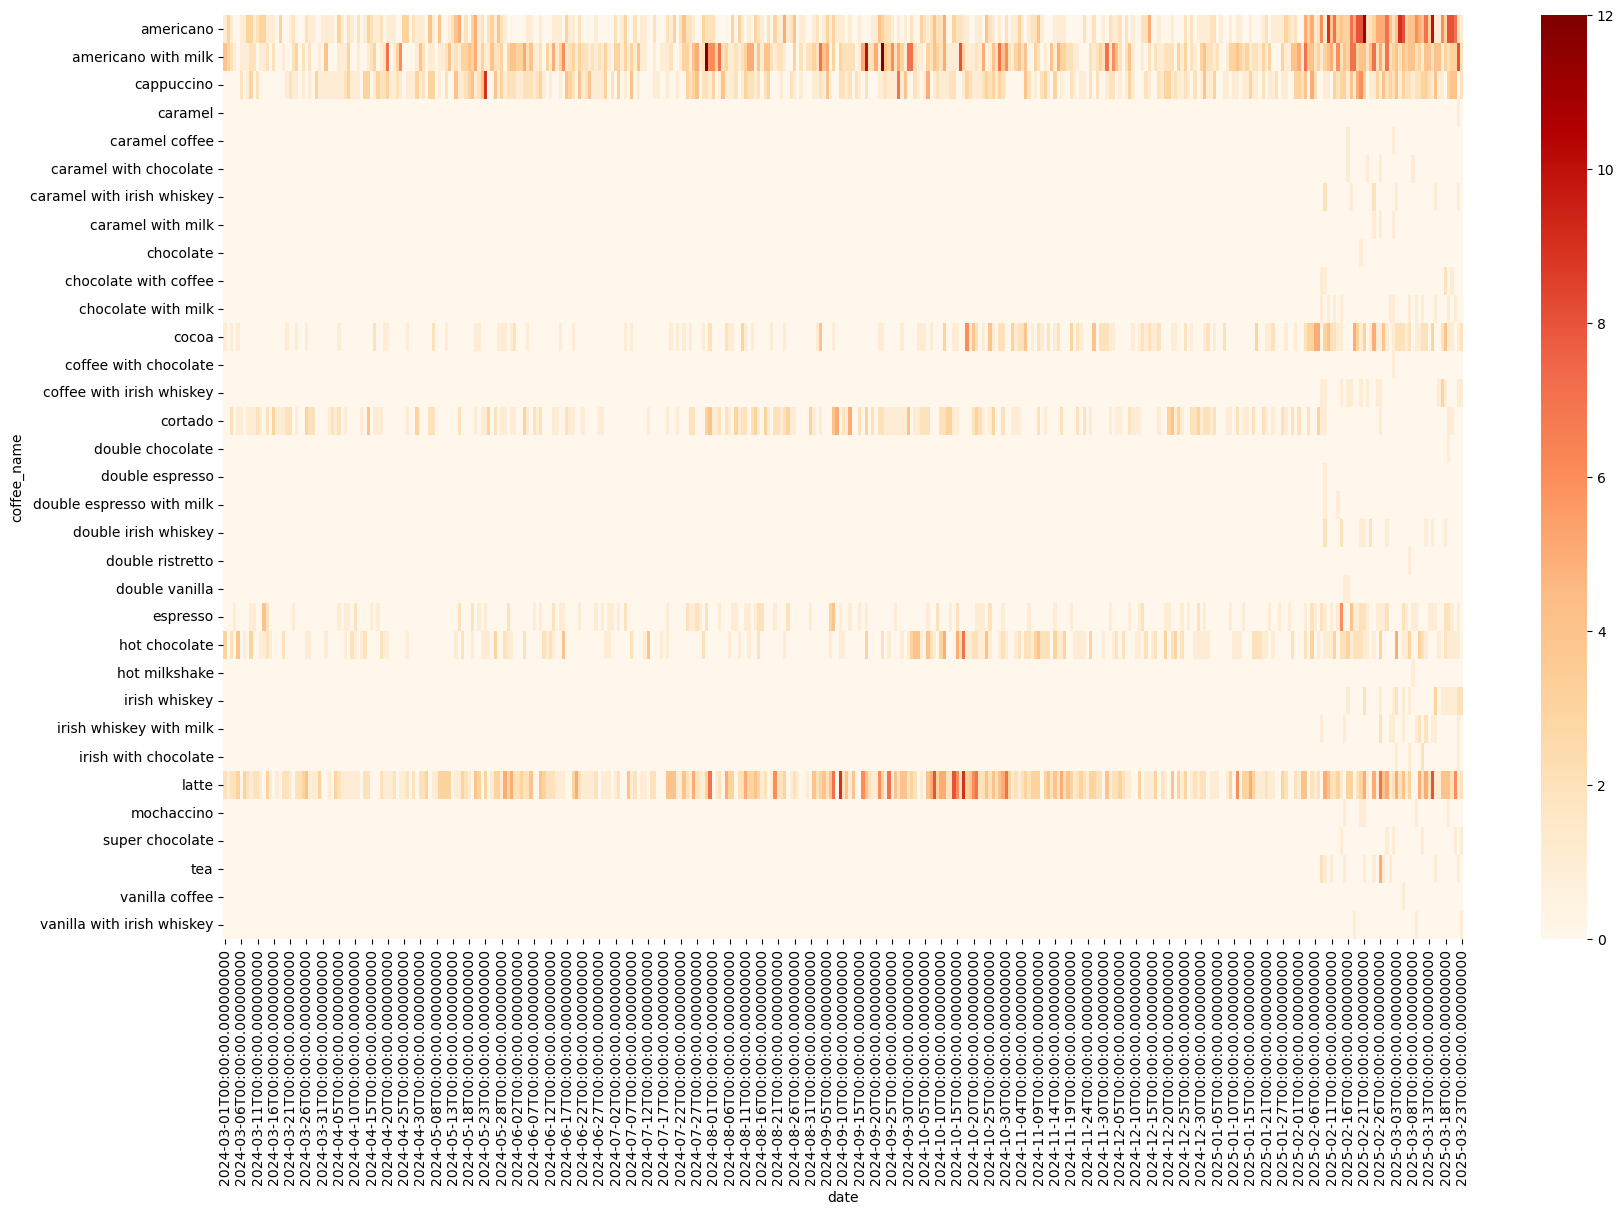

In [5]:
#DAILY AGGREGATION
daily_counts = data.groupby(['date', 'coffee_name']).size().reset_index(name='count')    
pivot_data = daily_counts.pivot(index='date', columns='coffee_name', values='count').fillna(0)
heatmap_data = pivot_data.T  # Transpose: coffee types as rows
pyplot.figure(figsize=(20, 12))
seaborn.heatmap(heatmap_data, cmap='OrRd')

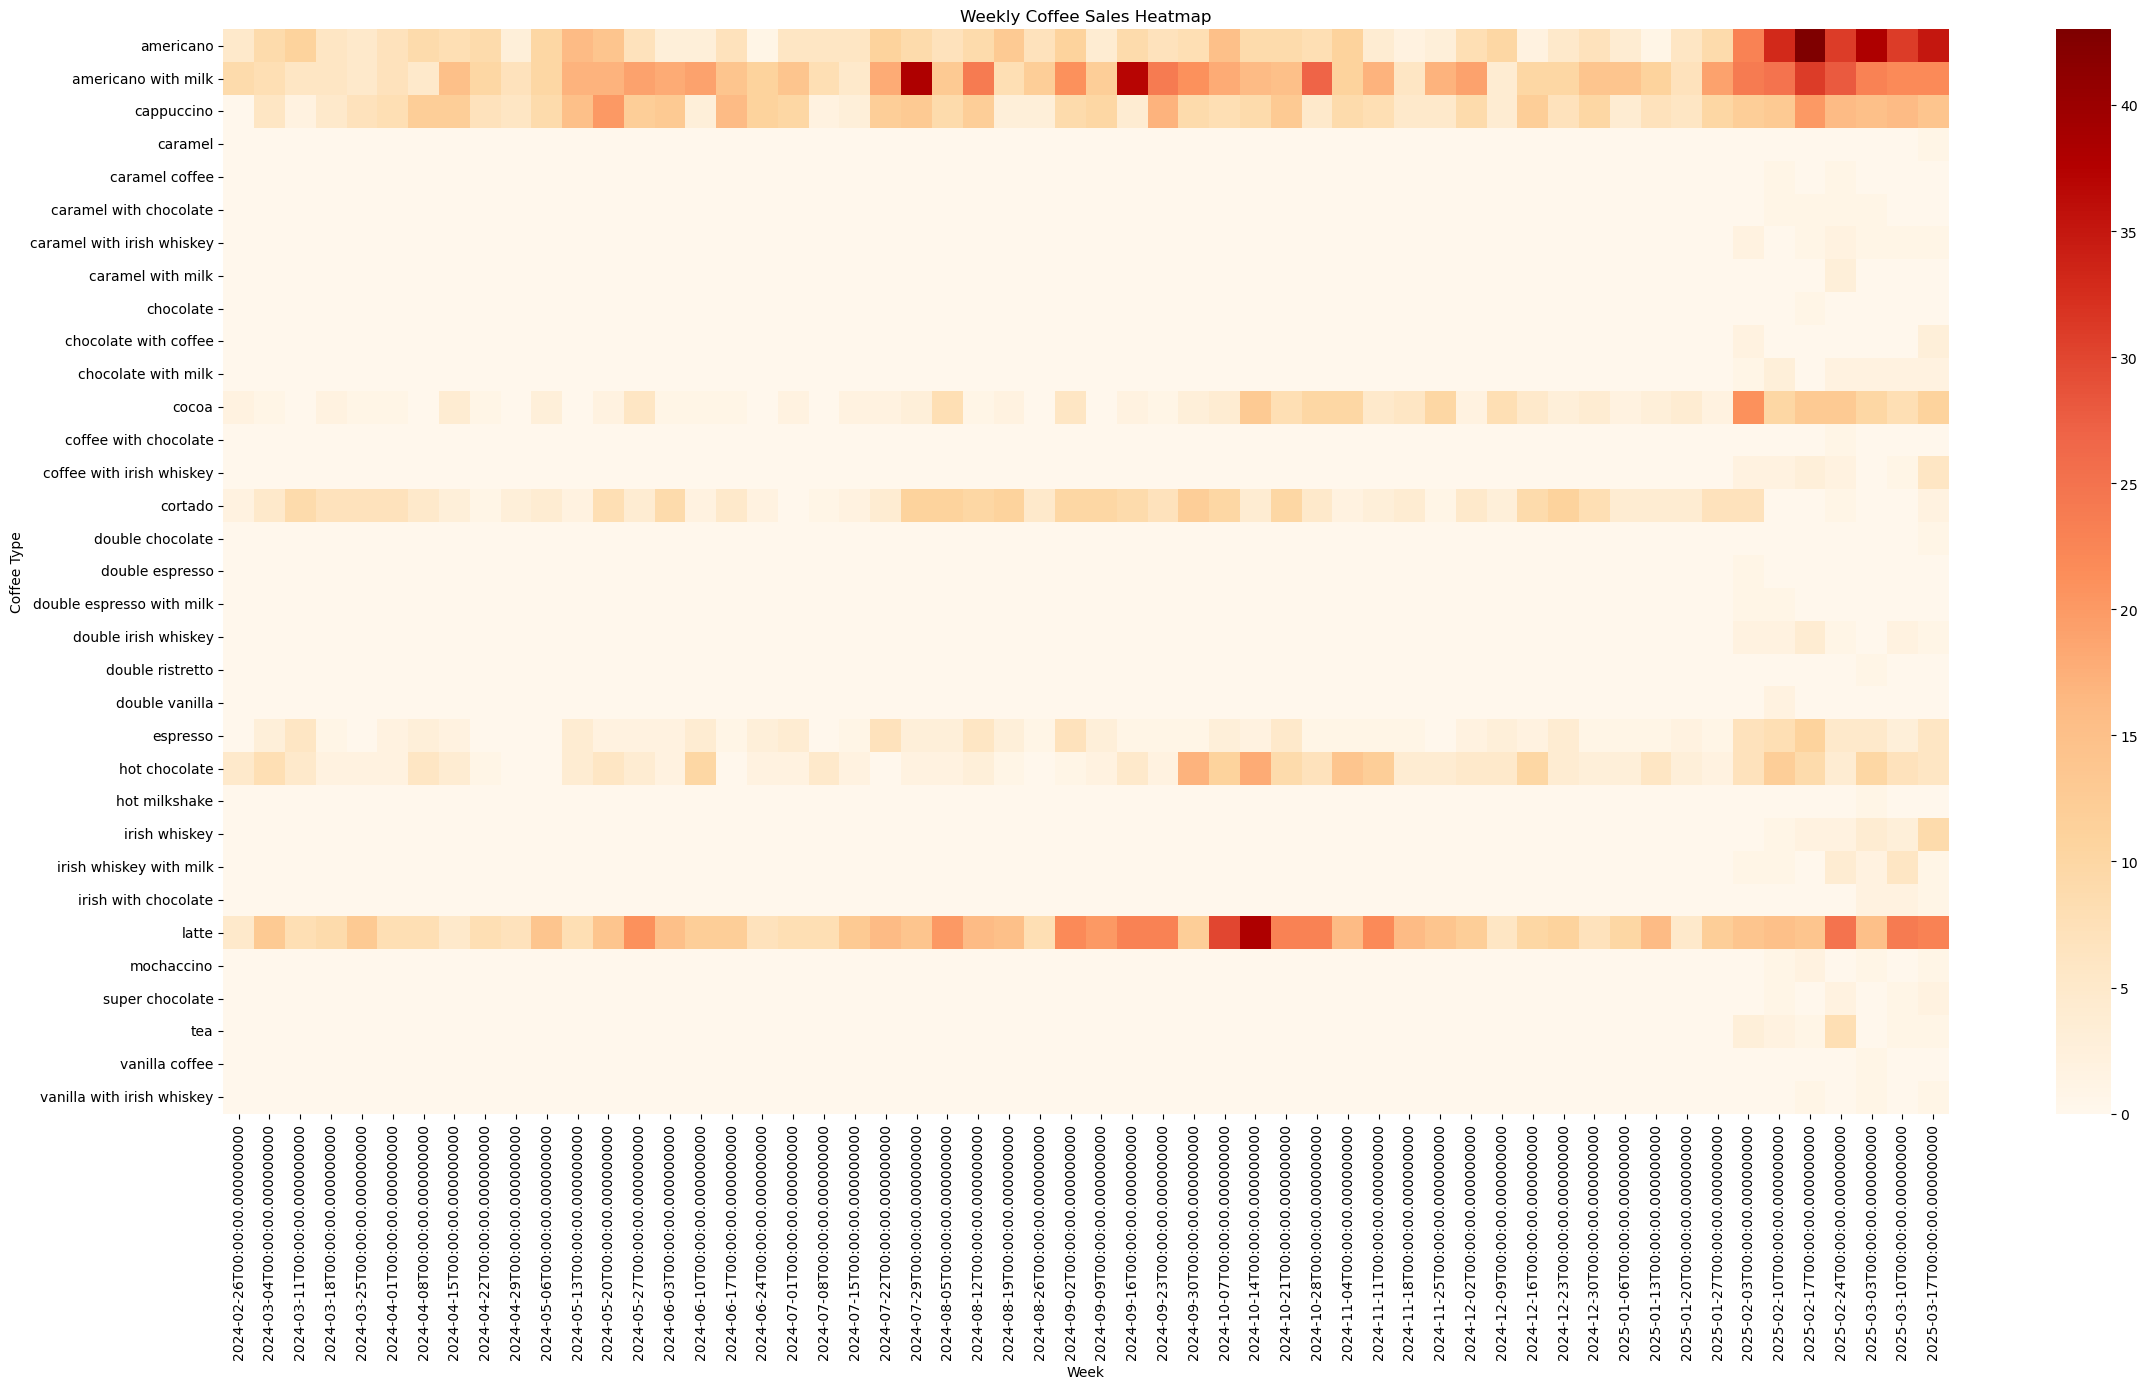

In [6]:
# WEEKLY AGGREGATION
data['week'] = data['date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_counts = data.groupby(['week', 'coffee_name']).size().reset_index(name='count')
weekly_pivot = weekly_counts.pivot(index='week', columns='coffee_name', values='count').fillna(0)
weekly_heatmap = weekly_pivot.T

pyplot.figure(figsize=(24, 14))
seaborn.heatmap(weekly_heatmap, cmap='OrRd')
pyplot.title("Weekly Coffee Sales Heatmap")
pyplot.xlabel("Week")
pyplot.ylabel("Coffee Type")
pyplot.tight_layout()
pyplot.show()

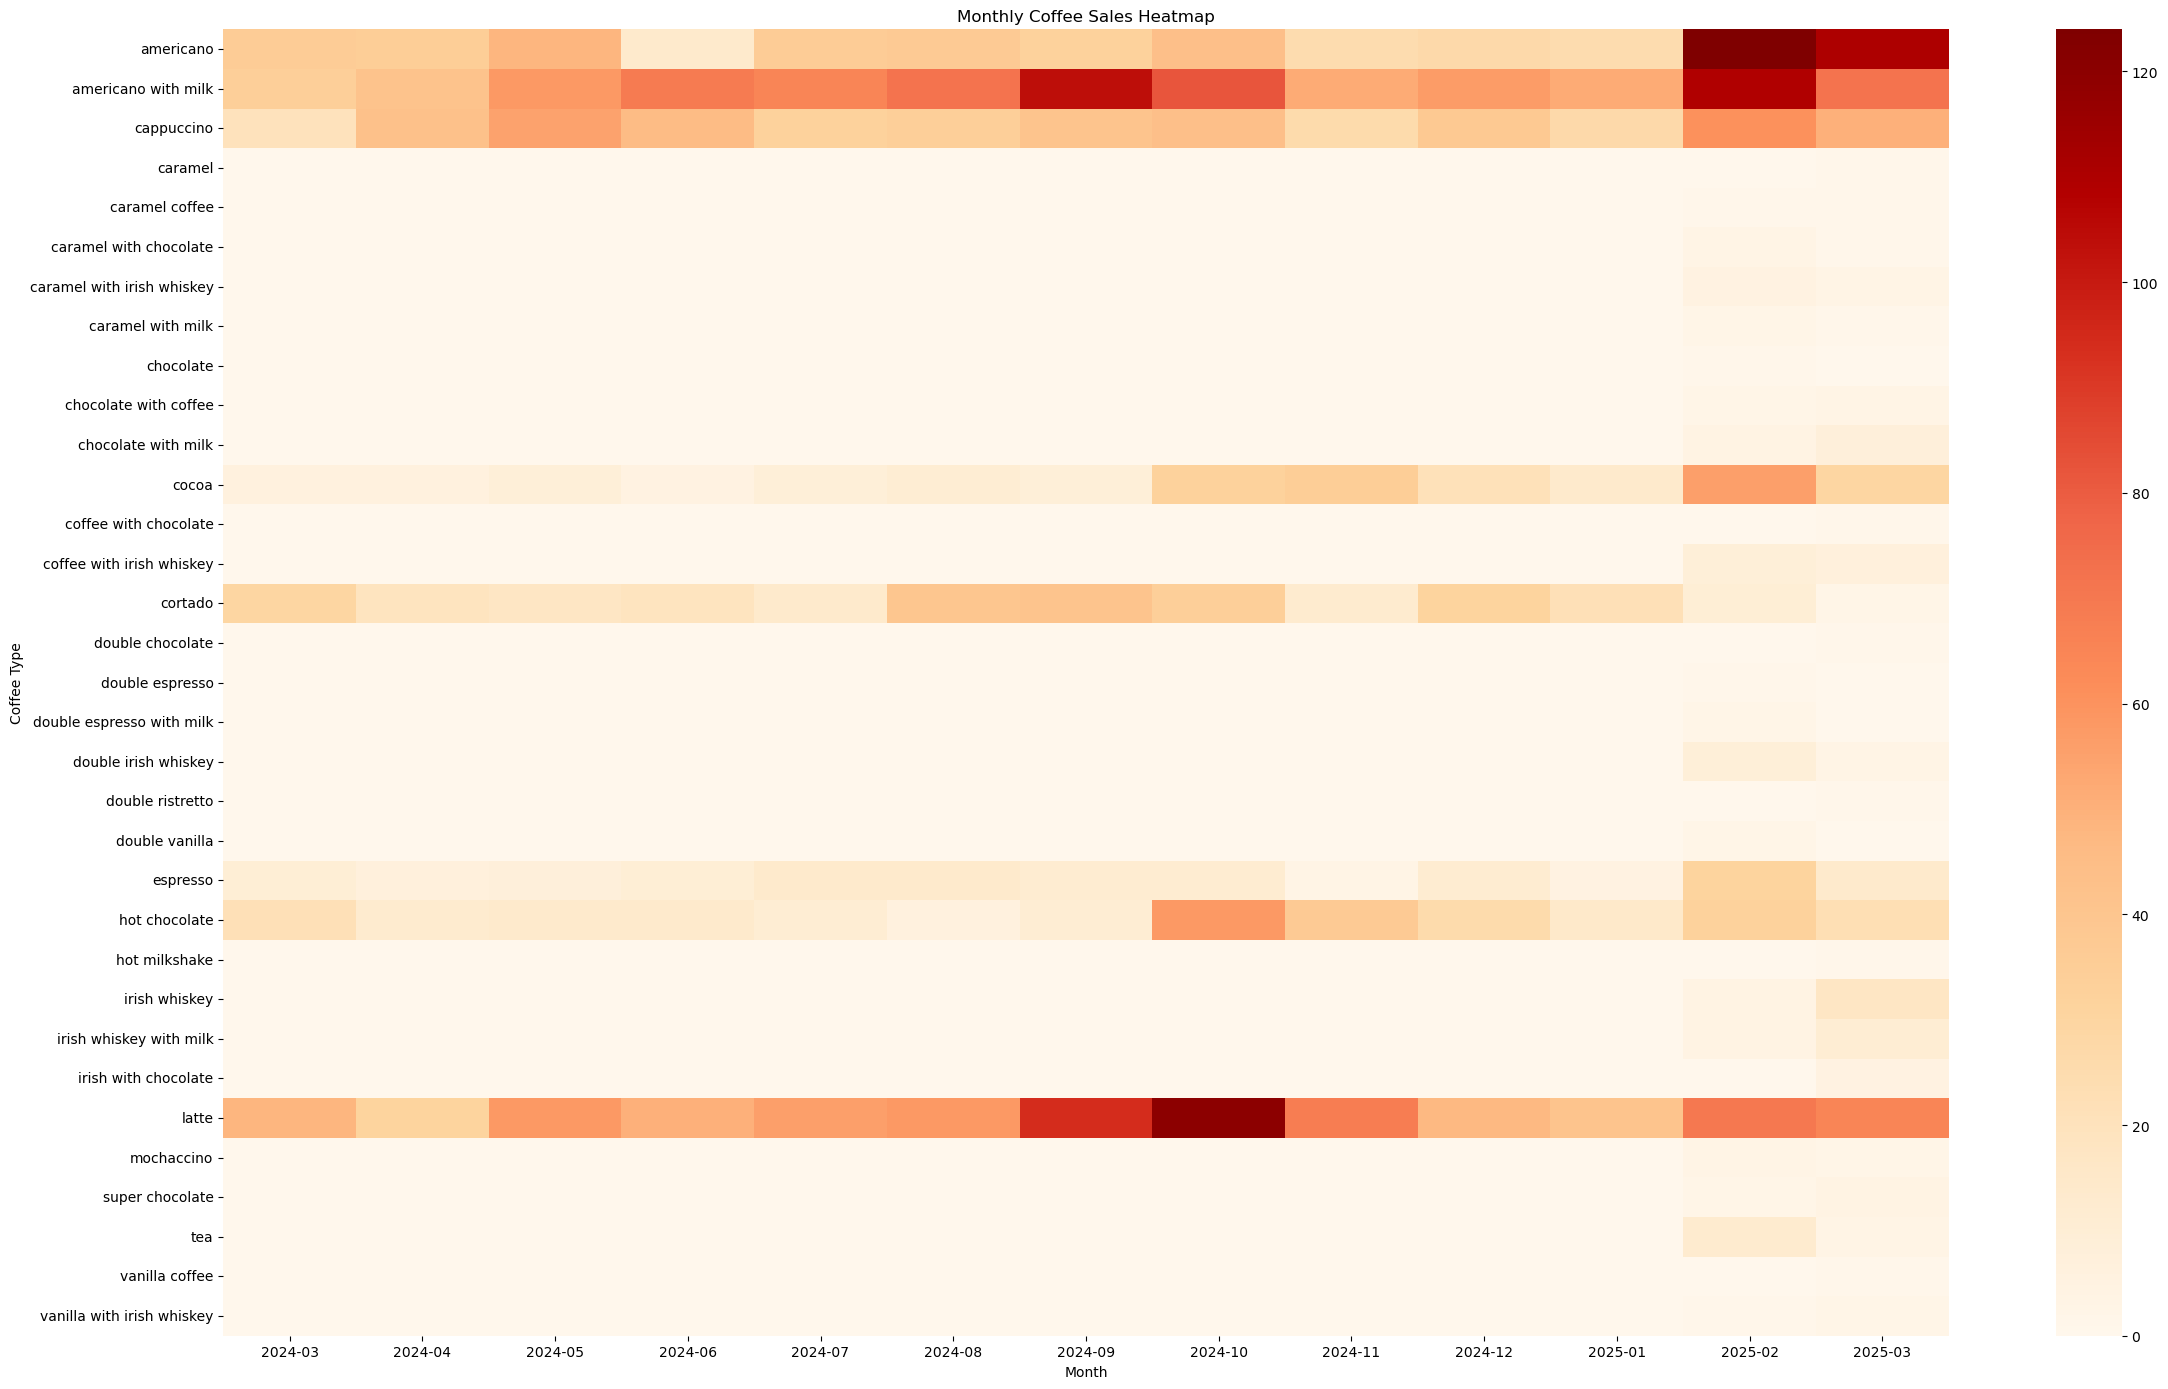

In [7]:
# MONTHLY AGGREGATION
data['month'] = data['date'].dt.to_period('M').astype(str)
monthly_counts = data.groupby(['month', 'coffee_name']).size().reset_index(name='count')
monthly_pivot = monthly_counts.pivot(index='month', columns='coffee_name', values='count').fillna(0)
monthly_heatmap = monthly_pivot.T

pyplot.figure(figsize=(24, 14))
seaborn.heatmap(monthly_heatmap, cmap='OrRd')
pyplot.title("Monthly Coffee Sales Heatmap")
pyplot.xlabel("Month")
pyplot.ylabel("Coffee Type")
pyplot.tight_layout()
pyplot.show()

In [8]:
data['date'] = pandas.to_datetime(data['date'])
data['week_start'] = data['date'] - pandas.to_timedelta(data['date'].dt.weekday, unit='D')

# Group by week_start and coffee_name
weekly_summary = (
    data.groupby(['week_start', 'coffee_name'])
      .agg(
          cups_bought=('coffee_name', 'count'),
          total_spent=('money', 'sum')
      )
      .reset_index()
)

print(weekly_summary)

    week_start                 coffee_name  cups_bought  total_spent
0   2024-02-26                   americano            5        144.5
1   2024-02-26         americano with milk            9        304.2
2   2024-02-26                       cocoa            2         77.4
3   2024-02-26                     cortado            2         57.8
4   2024-02-26               hot chocolate            5        193.5
..         ...                         ...          ...          ...
493 2025-03-17                       latte           23        814.2
494 2025-03-17                  mochaccino            1         30.0
495 2025-03-17             super chocolate            2         56.0
496 2025-03-17                         tea            1         15.0
497 2025-03-17  vanilla with irish whiskey            1         28.0

[498 rows x 4 columns]


In [9]:
weekly_pivot = (
    data.groupby(['week_start', 'coffee_name'])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

In [10]:
less_bought_data = weekly_pivot.drop(columns=['americano', 'americano with milk', 'cappuccino', 'latte', 'cocoa', 'cortado', 'hot chocolate', 'espresso'])
less_bought_data

coffee_name,week_start,caramel,caramel coffee,caramel with chocolate,caramel with irish whiskey,caramel with milk,chocolate,chocolate with coffee,chocolate with milk,coffee with chocolate,...,double vanilla,hot milkshake,irish whiskey,irish whiskey with milk,irish with chocolate,mochaccino,super chocolate,tea,vanilla coffee,vanilla with irish whiskey
0,2024-02-26,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2024-03-04,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2024-03-11,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2024-03-18,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2024-03-25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,2024-04-01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2024-04-08,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,2024-04-15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,2024-04-22,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,2024-04-29,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
def first_nonzero_week(df, group_col='week_start'):
    results = {}
    # Iterate over all columns except the grouping column
    for col in df.columns:
        if col == group_col:
            continue
        # Find rows where column != 0
        nonzero = df[df[col] != 0]
        if not nonzero.empty:
            # Take the first occurrence
            first_week = nonzero[group_col].iloc[0]
            results[col] = first_week
        else:
            results[col] = None  # no nonzero values
    return results

first_weeks = first_nonzero_week(less_bought_data)
for name, date in first_weeks.items():
    print(f"{date} - {name}")

2025-03-17 00:00:00 - caramel
2025-02-10 00:00:00 - caramel coffee
2025-02-10 00:00:00 - caramel with chocolate
2025-02-03 00:00:00 - caramel with irish whiskey
2025-02-24 00:00:00 - caramel with milk
2025-02-17 00:00:00 - chocolate
2025-02-03 00:00:00 - chocolate with coffee
2025-02-03 00:00:00 - chocolate with milk
2025-02-24 00:00:00 - coffee with chocolate
2025-02-03 00:00:00 - coffee with irish whiskey
2025-03-17 00:00:00 - double chocolate
2025-02-03 00:00:00 - double espresso
2025-02-03 00:00:00 - double espresso with milk
2025-02-03 00:00:00 - double irish whiskey
2025-03-03 00:00:00 - double ristretto
2025-02-10 00:00:00 - double vanilla
2025-03-03 00:00:00 - hot milkshake
2025-02-10 00:00:00 - irish whiskey
2025-02-03 00:00:00 - irish whiskey with milk
2025-03-03 00:00:00 - irish with chocolate
2025-02-10 00:00:00 - mochaccino
2025-02-10 00:00:00 - super chocolate
2025-02-03 00:00:00 - tea
2025-03-03 00:00:00 - vanilla coffee
2025-02-17 00:00:00 - vanilla with irish whiskey


In [12]:
total_per_type = (
    data.groupby('coffee_name')
      .size()
      .reset_index(name='cups_bought')
      .sort_values(by='cups_bought', ascending=False)
)

print(total_per_type)

                   coffee_name  cups_bought
1          americano with milk          868
27                       latte          806
0                    americano          593
2                   cappuccino          517
14                     cortado          292
22               hot chocolate          282
11                       cocoa          243
21                    espresso          152
24               irish whiskey           21
13   coffee with irish whiskey           16
30                         tea           16
25     irish whiskey with milk           15
18        double irish whiskey           12
10         chocolate with milk           12
6   caramel with irish whiskey            8
29             super chocolate            6
9        chocolate with coffee            5
28                  mochaccino            5
26        irish with chocolate            5
5       caramel with chocolate            4
32  vanilla with irish whiskey            3
7            caramel with milk  

In [13]:
from IPython.display import display, HTML

data['month'] = data['date'].dt.to_period('M')

monthly_pivot = (
    data.groupby(['month', 'coffee_name'])
        .size()
        .unstack(fill_value=0)
        .reset_index()
).sort_values(by='month', ascending=False)

html_table = monthly_pivot.to_html()
display(HTML(f"<div style='overflow-x: auto; max-height:400px;'>{html_table}</div>"))

coffee_name,month,americano,americano with milk,cappuccino,caramel,caramel coffee,caramel with chocolate,caramel with irish whiskey,caramel with milk,chocolate,chocolate with coffee,chocolate with milk,cocoa,coffee with chocolate,coffee with irish whiskey,cortado,double chocolate,double espresso,double espresso with milk,double irish whiskey,double ristretto,double vanilla,espresso,hot chocolate,hot milkshake,irish whiskey,irish whiskey with milk,irish with chocolate,latte,mochaccino,super chocolate,tea,vanilla coffee,vanilla with irish whiskey
12,2025-03,110,72,50,1,1,1,3,1,0,3,8,30,1,7,2,1,0,0,3,1,0,14,23,1,17,11,5,65,2,4,3,1,2
11,2025-02,124,109,61,0,1,3,5,2,1,2,4,56,0,9,10,0,1,2,9,0,2,31,32,0,4,4,0,70,3,2,13,0,1
10,2025-01,25,52,27,0,0,0,0,0,0,0,0,14,0,0,22,0,0,0,0,0,0,5,15,0,0,0,0,41,0,0,0,0,0
9,2024-12,27,57,38,0,0,0,0,0,0,0,0,21,0,0,31,0,0,0,0,0,0,12,26,0,0,0,0,47,0,0,0,0,0
8,2024-11,25,52,26,0,0,0,0,0,0,0,0,35,0,0,13,0,0,0,0,0,0,3,37,0,0,0,0,68,0,0,0,0,0
7,2024-10,44,82,44,0,0,0,0,0,0,0,0,32,0,0,34,0,0,0,0,0,0,12,58,0,0,0,0,120,0,0,0,0,0
6,2024-09,32,104,41,0,0,0,0,0,0,0,0,9,0,0,41,0,0,0,0,0,0,12,11,0,0,0,0,94,0,0,0,0,0
5,2024-08,37,72,34,0,0,0,0,0,0,0,0,11,0,0,40,0,0,0,0,0,0,14,6,0,0,0,0,58,0,0,0,0,0
4,2024-07,36,65,32,0,0,0,0,0,0,0,0,9,0,0,14,0,0,0,0,0,0,14,11,0,0,0,0,56,0,0,0,0,0
3,2024-06,14,69,46,0,0,0,0,0,0,0,0,5,0,0,19,0,0,0,0,0,0,10,14,0,0,0,0,50,0,0,0,0,0


In [14]:
def sum_diff_between_dates(monthly_pivot, date1, date2, coffee_names):
    if monthly_pivot['month'].dtype != 'period[M]':
        monthly_pivot['month'] = monthly_pivot['month'].astype('period[M]')

    row1 = monthly_pivot.loc[monthly_pivot['month'] == pandas.Period(date1, freq='M')]
    row2 = monthly_pivot.loc[monthly_pivot['month'] == pandas.Period(date2, freq='M')]

    if row1.empty or row2.empty:
        raise ValueError("One of the dates is not present in monthly_pivot")

    diff_sum = (row2[coffee_names].values - row1[coffee_names].values).sum()

    return diff_sum

result = sum_diff_between_dates(monthly_pivot, '2025-02', '2025-03', ['americano with milk','latte','americano','cappuccino','cortado','hot chocolate','cocoa','espresso'])
print("Sum of differences:", result)

result2 = sum_diff_between_dates(monthly_pivot, '2025-02', '2025-03', ['irish whiskey','coffee with irish whiskey','tea','irish whiskey with milk','double irish whiskey'])
print("Sum of differences:", result2)

Sum of differences: -127
Sum of differences: 2


In [15]:
def median_purchase_time_per_month_pivot(df):
    # Work on a copy to avoid mutating the original
    d = df.copy()

    # Ensure datetime is proper dtype
    d['datetime'] = pandas.to_datetime(d['datetime'])

    # Month as Period[M]
    d['month'] = d['datetime'].dt.to_period('M')

    # Convert time-of-day to seconds since midnight (float to keep micros, then round)
    secs = (
        d['datetime'].dt.hour * 3600
        + d['datetime'].dt.minute * 60
        + d['datetime'].dt.second
        + d['datetime'].dt.microsecond / 1_000_000
    )
    d['seconds_since_midnight'] = secs

    # Median seconds per (month, coffee_name)
    grouped = (
        d.groupby(['month', 'coffee_name'])['seconds_since_midnight']
         .median()
         .round()  # round to nearest second
         .astype(int)
         .reset_index()
    )

    # Convert seconds back to HH:MM:SS strings
    grouped['median_time'] = pandas.to_timedelta(grouped['seconds_since_midnight'], unit='s')\
                                .astype('timedelta64[s]')\
                                .astype(int)
    grouped['median_time'] = pandas.to_timedelta(grouped['median_time'], unit='s')\
                                .apply(lambda td: str(td))  # yields HH:MM:SS

    # Pivot to have coffee types as columns
    pivoted = grouped.pivot(index='month', columns='coffee_name', values='median_time')\
                     .reset_index()

    # Optional: sort months descending
    pivoted = pivoted.sort_values(by='month', ascending=False)

    return pivoted


median_purchase_time_per_month_pivot = median_purchase_time_per_month_pivot(data)
html_table = median_purchase_time_per_month_pivot.to_html()
display(HTML(f"<div style='overflow-x: auto; max-height:400px;'>{html_table}</div>"))

coffee_name,month,americano,americano with milk,cappuccino,caramel,caramel coffee,caramel with chocolate,caramel with irish whiskey,caramel with milk,chocolate,chocolate with coffee,chocolate with milk,cocoa,coffee with chocolate,coffee with irish whiskey,cortado,double chocolate,double espresso,double espresso with milk,double irish whiskey,double ristretto,double vanilla,espresso,hot chocolate,hot milkshake,irish whiskey,irish whiskey with milk,irish with chocolate,latte,mochaccino,super chocolate,tea,vanilla coffee,vanilla with irish whiskey
12,2025-03,0 days 12:12:02,0 days 12:34:40,0 days 14:40:08,0 days 17:58:01,0 days 12:16:41,0 days 21:48:58,0 days 16:23:33,0 days 20:30:04,NaN,0 days 19:35:21,0 days 18:28:40,0 days 16:22:33,0 days 12:48:05,0 days 17:33:56,0 days 16:27:27,0 days 19:42:58,NaN,NaN,0 days 15:02:02,0 days 12:36:33,NaN,0 days 15:09:50,0 days 12:55:38,0 days 21:32:09,0 days 13:37:40,0 days 16:35:56,0 days 14:19:54,0 days 15:54:20,0 days 16:24:59,0 days 16:26:50,0 days 13:12:26,0 days 11:39:26,0 days 18:03:16
11,2025-02,0 days 13:08:30,0 days 13:02:19,0 days 14:59:22,NaN,0 days 23:04:57,0 days 16:38:30,0 days 18:02:39,0 days 18:44:14,0 days 13:20:58,0 days 13:16:20,0 days 18:09:38,0 days 17:10:58,NaN,0 days 19:05:11,0 days 15:40:47,NaN,0 days 10:42:55,0 days 11:57:46,0 days 16:13:01,NaN,0 days 13:56:08,0 days 13:43:42,0 days 15:55:22,NaN,0 days 10:09:26,0 days 15:15:23,NaN,0 days 16:36:04,0 days 09:20:59,0 days 19:54:04,0 days 13:23:23,NaN,0 days 09:52:42
10,2025-01,0 days 13:02:00,0 days 11:53:08,0 days 15:36:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 14:55:20,NaN,NaN,0 days 13:23:16,NaN,NaN,NaN,NaN,NaN,NaN,0 days 14:27:23,0 days 17:39:10,NaN,NaN,NaN,NaN,0 days 15:37:55,NaN,NaN,NaN,NaN,NaN
9,2024-12,0 days 13:32:47,0 days 11:43:15,0 days 17:20:26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 17:47:27,NaN,NaN,0 days 11:04:25,NaN,NaN,NaN,NaN,NaN,NaN,0 days 15:35:18,0 days 16:20:18,NaN,NaN,NaN,NaN,0 days 15:44:04,NaN,NaN,NaN,NaN,NaN
8,2024-11,0 days 14:04:55,0 days 13:18:24,0 days 16:16:32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 13:18:24,NaN,NaN,0 days 10:38:08,NaN,NaN,NaN,NaN,NaN,NaN,0 days 11:45:31,0 days 18:12:53,NaN,NaN,NaN,NaN,0 days 14:17:05,NaN,NaN,NaN,NaN,NaN
7,2024-10,0 days 13:24:36,0 days 12:19:21,0 days 14:30:26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 14:10:38,NaN,NaN,0 days 10:32:16,NaN,NaN,NaN,NaN,NaN,NaN,0 days 12:57:32,0 days 19:57:17,NaN,NaN,NaN,NaN,0 days 14:39:30,NaN,NaN,NaN,NaN,NaN
6,2024-09,0 days 17:40:56,0 days 13:55:25,0 days 16:29:37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 11:02:13,NaN,NaN,0 days 11:37:47,NaN,NaN,NaN,NaN,NaN,NaN,0 days 11:09:11,0 days 20:15:50,NaN,NaN,NaN,NaN,0 days 15:35:12,NaN,NaN,NaN,NaN,NaN
5,2024-08,0 days 12:13:40,0 days 12:05:56,0 days 14:28:07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 20:49:30,NaN,NaN,0 days 10:40:40,NaN,NaN,NaN,NaN,NaN,NaN,0 days 12:33:56,0 days 10:52:46,NaN,NaN,NaN,NaN,0 days 16:20:33,NaN,NaN,NaN,NaN,NaN
4,2024-07,0 days 11:11:24,0 days 12:07:01,0 days 16:56:29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 14:11:22,NaN,NaN,0 days 14:51:41,NaN,NaN,NaN,NaN,NaN,NaN,0 days 14:37:15,0 days 19:29:25,NaN,NaN,NaN,NaN,0 days 15:16:50,NaN,NaN,NaN,NaN,NaN
3,2024-06,0 days 13:10:54,0 days 18:12:01,0 days 17:07:27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 20:10:47,NaN,NaN,0 days 10:13:37,NaN,NaN,NaN,NaN,NaN,NaN,0 days 15:16:34,0 days 17:09:46,NaN,NaN,NaN,NaN,0 days 15:16:30,NaN,NaN,NaN,NaN,NaN


In [16]:
cocoa_data = data[data['coffee_name'] == 'caramel coffee'][['coffee_name','date', 'datetime']].sort_values(by='datetime', ascending=True)
html_table = cocoa_data.to_html()
display(HTML(f"<div style='overflow-x: auto; max-height:400px;'>{html_table}</div>"))

,coffee_name,date,datetime
3693,caramel coffee,2025-02-16,2025-02-16 23:04:57
3781,caramel coffee,2025-03-02,2025-03-02 12:16:41


In [17]:
def overall_median_time_per_beverage(monthly_pivot):
    # Work on a copy
    df = monthly_pivot.drop(columns=['month']).copy()
    
    # Robust conversion to seconds since midnight
    def to_seconds(t):
        if pandas.isna(t):
            return None
        t = str(t).strip()
        # Handle "0 days HH:MM:SS" or "HH:MM:SS"
        if "days" in t:
            # keep only the time part after "days"
            t = t.split("days")[-1].strip()
        h, m, s = map(int, t.split(':'))
        return h*3600 + m*60 + s
    
    # Apply conversion column by column
    df_seconds = df.apply(lambda col: col.map(to_seconds))
    
    # Compute median per beverage (column)
    medians = df_seconds.median(skipna=True)
    
    # Convert back to HH:MM:SS
    def to_hms(sec):
        if pandas.isna(sec):
            return None
        sec = int(round(sec))
        h = sec // 3600
        m = (sec % 3600) // 60
        s = sec % 60
        return f"{h:02d}:{m:02d}:{s:02d}"
    
    return medians.apply(to_hms)

result_total_per_beverage = overall_median_time_per_beverage(median_purchase_time_per_month_pivot)
print(result_total_per_beverage)

coffee_name
americano                     13:24:36
americano with milk           13:02:19
cappuccino                    16:16:32
caramel                       17:58:01
caramel coffee                17:40:49
caramel with chocolate        19:13:44
caramel with irish whiskey    17:13:06
caramel with milk             19:37:09
chocolate                     13:20:58
chocolate with coffee         16:25:50
chocolate with milk           18:19:09
cocoa                         16:22:33
coffee with chocolate         12:48:05
coffee with irish whiskey     18:19:34
cortado                       13:23:16
double chocolate              19:42:58
double espresso               10:42:55
double espresso with milk     11:57:46
double irish whiskey          15:37:32
double ristretto              12:36:33
double vanilla                13:56:08
espresso                      14:27:23
hot chocolate                 17:39:10
hot milkshake                 21:32:09
irish whiskey                 11:53:33
irish whiskey

In [18]:
def overall_median_time_all_beverages(monthly_pivot):
    # Drop month column
    df = monthly_pivot.drop(columns=['month']).copy()
    
    # Flatten all values into one Series
    all_times = df.values.ravel()
    
    # Robust conversion to seconds
    def to_seconds(t):
        if pandas.isna(t):
            return None
        t = str(t).strip()
        if "days" in t:  # handle "0 days HH:MM:SS"
            t = t.split("days")[-1].strip()
        # handle fractional seconds
        parts = t.split(':')
        h, m = int(parts[0]), int(parts[1])
        s = int(float(parts[2]))  # cast fractional seconds safely
        return h*3600 + m*60 + s
    
    times_in_seconds = [to_seconds(t) for t in all_times if pandas.notna(t)]
    
    # Compute median
    median_sec = pandas.Series(times_in_seconds).median()
    
    # Convert back to HH:MM:SS
    h = int(median_sec // 3600)
    m = int((median_sec % 3600) // 60)
    s = int(median_sec % 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

overall_median = overall_median_time_all_beverages(median_purchase_time_per_month_pivot)
print("Overall median time across all beverages:", overall_median)

Overall median time across all beverages: 14:40:08


In [19]:
def overall_median_time_all_periods(df):
    # Ensure datetime column is proper dtype
    df = df.copy()
    df['datetime'] = pandas.to_datetime(df['datetime'])
    
    # Convert each datetime to seconds since midnight
    times_in_seconds = (
        df['datetime'].dt.hour * 3600
        + df['datetime'].dt.minute * 60
        + df['datetime'].dt.second
        + df['datetime'].dt.microsecond / 1_000_000
    )
    
    # Compute median
    median_sec = times_in_seconds.median()
    
    # Convert back to HH:MM:SS
    h = int(median_sec // 3600)
    m = int((median_sec % 3600) // 60)
    s = int(median_sec % 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

overall_median = overall_median_time_all_periods(data)
print("Overall median time across all beverages and periods:", overall_median)

Overall median time across all beverages and periods: 14:35:17


In [20]:
def min_time_in_pivot(pivot_df):
    # Drop month column
    df = pivot_df.drop(columns=['month']).copy()
    
    # Flatten all values into one list
    all_times = df.values.ravel()
    
    # Robust conversion to seconds
    def to_seconds(t):
        if pandas.isna(t):
            return None
        t = str(t).strip()
        if "days" in t:  # handle "0 days HH:MM:SS"
            t = t.split("days")[-1].strip()
        parts = t.split(':')
        h, m = int(parts[0]), int(parts[1])
        s = int(float(parts[2]))  # handle fractional seconds safely
        return h*3600 + m*60 + s
    
    times_in_seconds = [to_seconds(t) for t in all_times if pandas.notna(t)]
    
    # Find minimum
    min_sec = min(times_in_seconds)
    
    # Convert back to HH:MM:SS
    h = min_sec // 3600
    m = (min_sec % 3600) // 60
    s = min_sec % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

min_time = min_time_in_pivot(median_purchase_time_per_month_pivot)
print("Earliest median time across all beverages and months:", min_time)

# identify the week day, when vending machine is filled in

Earliest median time across all beverages and months: 09:20:59


In [21]:
def monthly_money_pivot(df):
    # Ensure datetime column is proper dtype
    df = df.copy()
    df['date'] = pandas.to_datetime(df['date'])
    
    # Extract month as Period[M]
    df['month'] = df['date'].dt.to_period('M')
    
    # Group by month and coffee_name, sum money
    pivot = (
        df.groupby(['month', 'coffee_name'])['money']
          .sum()
          .unstack(fill_value=0)
          .reset_index()
          .sort_values(by='month')
    )
    
    return pivot

monthly_money_pivot = monthly_money_pivot(data)
html_table = monthly_money_pivot.to_html()
display(HTML(f"<div style='overflow-x: auto; max-height:400px;'>{html_table}</div>"))

coffee_name,month,americano,americano with milk,cappuccino,caramel,caramel coffee,caramel with chocolate,caramel with irish whiskey,caramel with milk,chocolate,chocolate with coffee,chocolate with milk,cocoa,coffee with chocolate,coffee with irish whiskey,cortado,double chocolate,double espresso,double espresso with milk,double irish whiskey,double ristretto,double vanilla,espresso,hot chocolate,hot milkshake,irish whiskey,irish whiskey with milk,irish with chocolate,latte,mochaccino,super chocolate,tea,vanilla coffee,vanilla with irish whiskey
0,2024-03,1044.80,1154.00,780.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,232.20,0.0,0.0,869.20,0.0,0.0,0.0,0.0,0.0,0.0,241.00,854.00,0.0,0.0,0.0,0.0,1874.50,0.0,0.0,0.0,0.0,0.0
1,2024-04,1001.94,1407.74,1659.44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,232.82,0.0,0.0,548.48,0.0,0.0,0.0,0.0,0.0,0.0,171.00,506.02,0.0,0.0,0.0,0.0,1193.12,0.0,0.0,0.0,0.0,0.0
2,2024-05,1348.80,1908.28,2078.44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,340.76,0.0,0.0,474.64,0.0,0.0,0.0,0.0,0.0,0.0,185.14,529.36,0.0,0.0,0.0,0.0,2198.00,0.0,0.0,0.0,0.0,0.0
3,2024-06,390.88,2268.12,1735.12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,189.88,0.0,0.0,530.48,0.0,0.0,0.0,0.0,0.0,0.0,230.20,528.08,0.0,0.0,0.0,0.0,1886.00,0.0,0.0,0.0,0.0,0.0
4,2024-07,858.12,1863.80,1079.64,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,300.28,0.0,0.0,322.28,0.0,0.0,0.0,0.0,0.0,0.0,273.28,361.02,0.0,0.0,0.0,0.0,1857.52,0.0,0.0,0.0,0.0,0.0
5,2024-08,851.74,2010.24,1115.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,361.02,0.0,0.0,920.80,0.0,0.0,0.0,0.0,0.0,0.0,253.68,196.92,0.0,0.0,0.0,0.0,1903.56,0.0,0.0,0.0,0.0,0.0
6,2024-09,739.58,2930.14,1360.32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,298.32,0.0,0.0,961.46,0.0,0.0,0.0,0.0,0.0,0.0,217.44,366.90,0.0,0.0,0.0,0.0,3114.48,0.0,0.0,0.0,0.0,0.0
7,2024-10,1142.24,2530.52,1573.44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1144.32,0.0,0.0,882.64,0.0,0.0,0.0,0.0,0.0,0.0,252.72,2074.08,0.0,0.0,0.0,0.0,4291.20,0.0,0.0,0.0,0.0,0.0
8,2024-11,649.00,1604.72,929.76,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1251.60,0.0,0.0,337.48,0.0,0.0,0.0,0.0,0.0,0.0,63.18,1323.12,0.0,0.0,0.0,0.0,2431.68,0.0,0.0,0.0,0.0,0.0
9,2024-12,700.92,1759.02,1358.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,750.96,0.0,0.0,804.76,0.0,0.0,0.0,0.0,0.0,0.0,252.72,929.76,0.0,0.0,0.0,0.0,1680.72,0.0,0.0,0.0,0.0,0.0


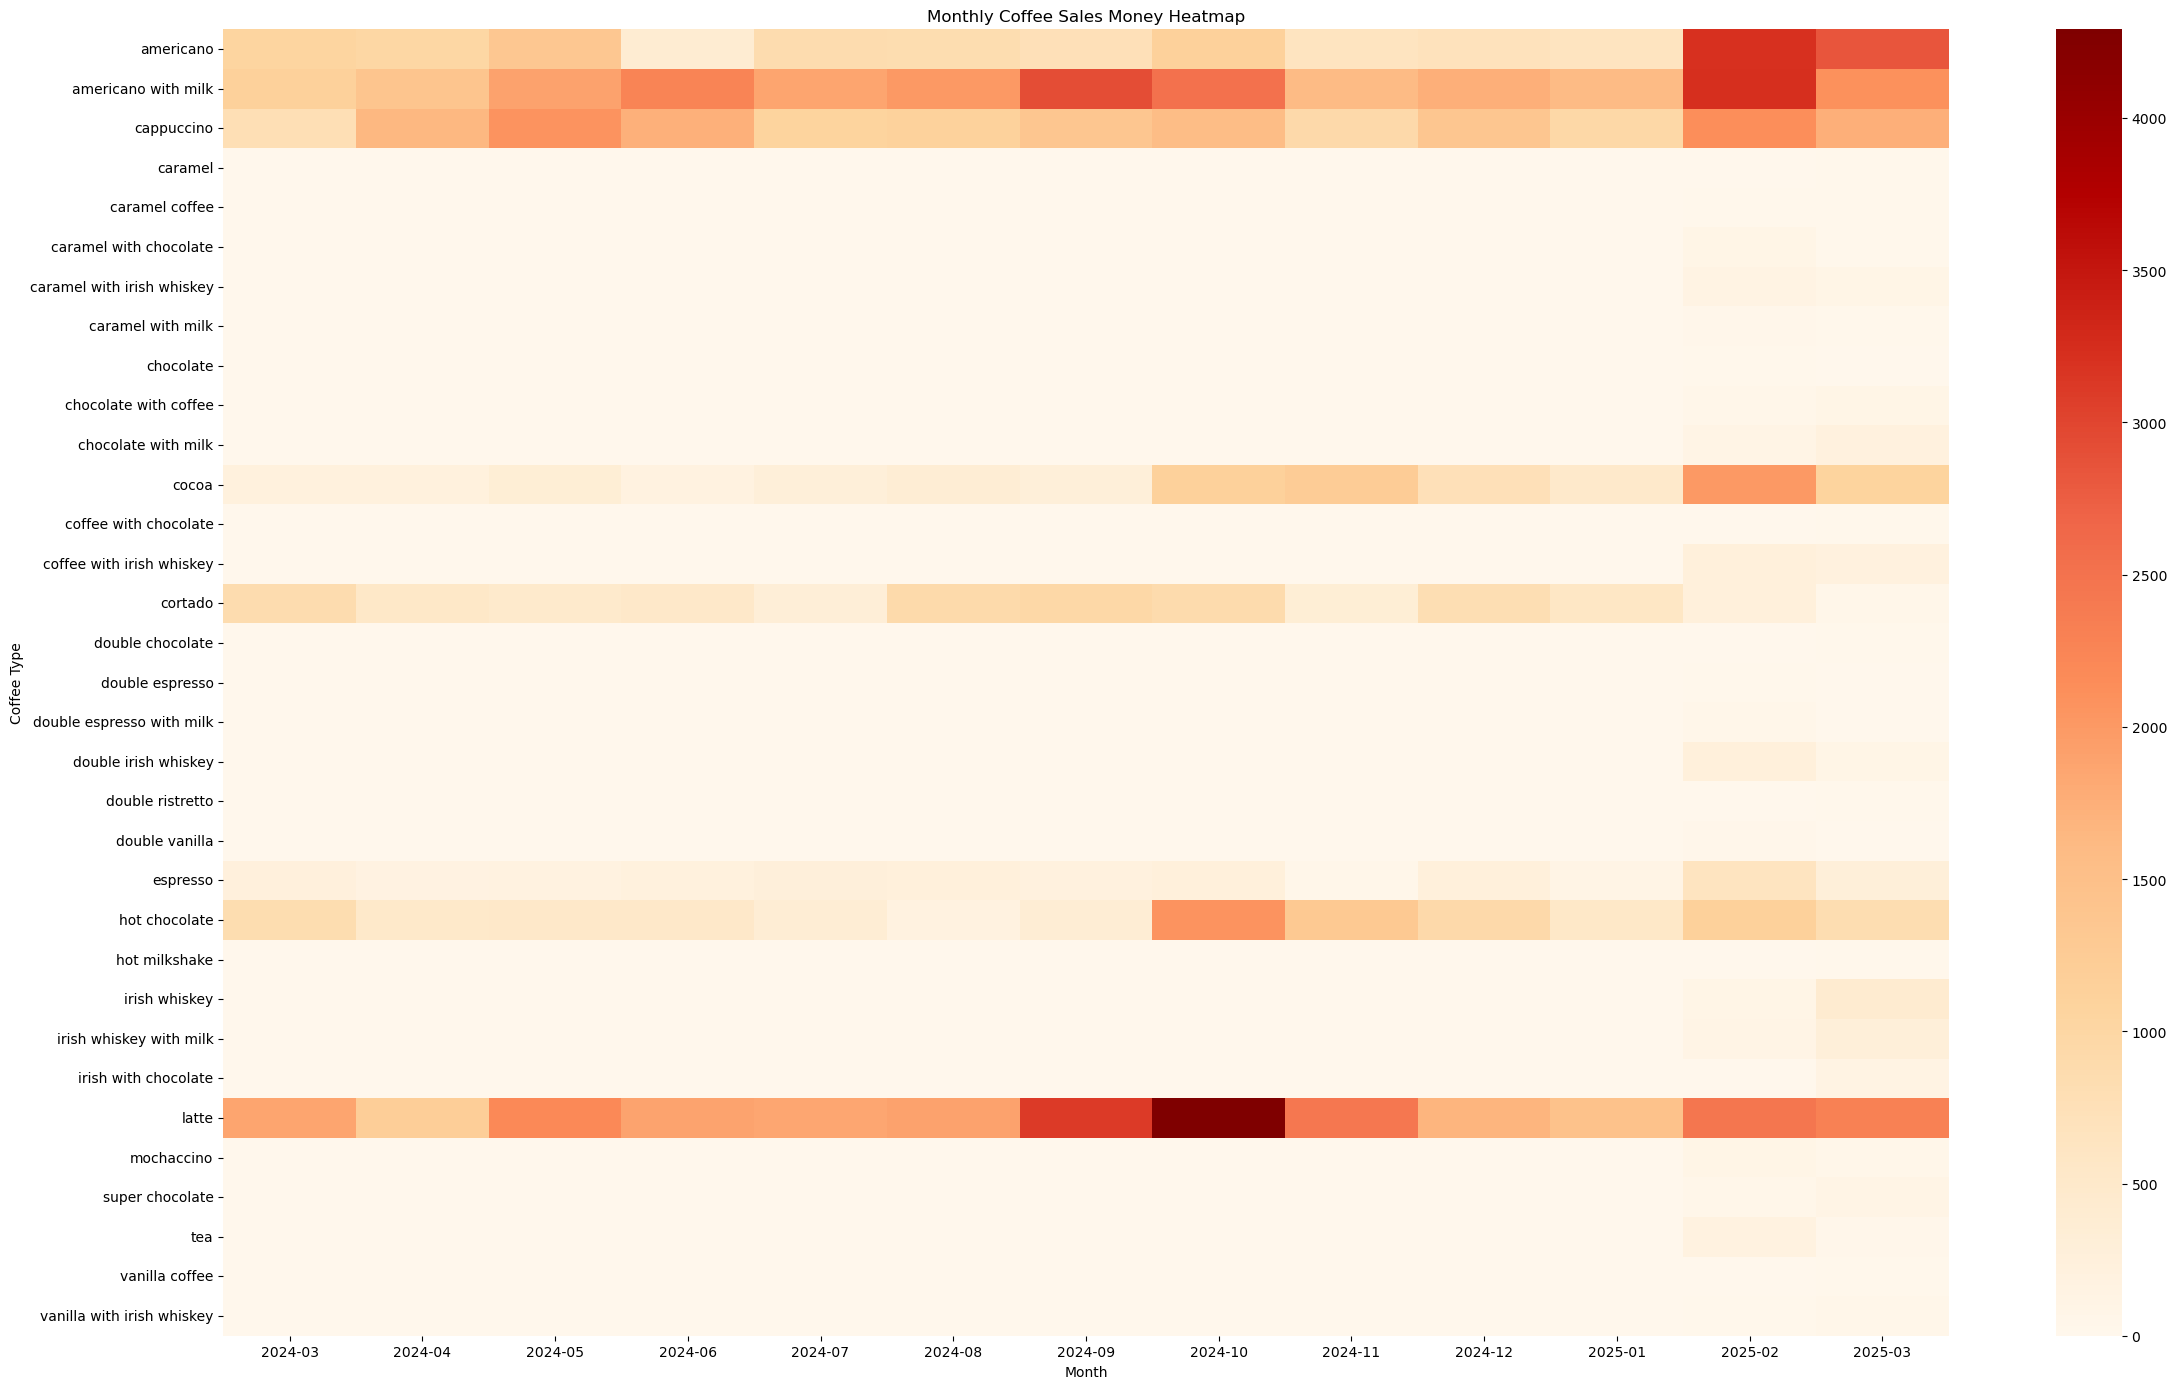

In [22]:
# Create pivot table with month as index (no reset_index)
monthly_money_pivot_indexed = (
    data.groupby([data['datetime'].dt.to_period('M'), 'coffee_name'])['money']
        .sum()
        .unstack(fill_value=0)
)

# Transpose for heatmap
monthly_money_heatmap = monthly_money_pivot_indexed.T

# Convert Period index to string for display
monthly_money_heatmap.columns = monthly_money_heatmap.columns.astype(str)

# Plot heatmap
pyplot.figure(figsize=(24, 14))
seaborn.heatmap(monthly_money_heatmap, cmap='OrRd')
pyplot.title("Monthly Coffee Sales Money Heatmap")
pyplot.xlabel("Month")
pyplot.ylabel("Coffee Type")
pyplot.tight_layout()
pyplot.show()

In [23]:
def monthly_price_pivot(df):
    # Ensure datetime column is proper dtype
    df = df.copy()
    df['datetime'] = pandas.to_datetime(df['datetime'])
    
    # Extract month as Period[M]
    df['month'] = df['datetime'].dt.to_period('M')
    
    # Group by month and coffee_name, collect unique prices
    grouped = (
        df.groupby(['month', 'coffee_name'])['money']
          .apply(lambda x: sorted(x.unique().tolist()))
          .unstack(fill_value=[])
    )
    
    # Reset index for cleaner display
    grouped = grouped.reset_index()
    
    return grouped

price_pivot = monthly_price_pivot(data)
html_table = price_pivot.to_html()
display(HTML(f"<div style='overflow-x: auto; max-height:400px;'>{html_table}</div>"))

coffee_name,month,americano,americano with milk,cappuccino,caramel,caramel coffee,caramel with chocolate,caramel with irish whiskey,caramel with milk,chocolate,chocolate with coffee,chocolate with milk,cocoa,coffee with chocolate,coffee with irish whiskey,cortado,double chocolate,double espresso,double espresso with milk,double irish whiskey,double ristretto,double vanilla,espresso,hot chocolate,hot milkshake,irish whiskey,irish whiskey with milk,irish with chocolate,latte,mochaccino,super chocolate,tea,vanilla coffee,vanilla with irish whiskey
0,2024-03,"[28.9, 30.0]","[33.8, 35.0]","[38.7, 40.0]",[],[],[],[],[],[],[],[],[38.7],[],[],"[28.9, 30.0]",[],[],[],[],[],[],"[24.0, 25.0]","[38.7, 40.0]",[],[],[],[],"[38.7, 40.0]",[],[],[],[],[]
1,2024-04,"[27.92, 28.9, 30.0]","[32.82, 33.8, 35.0]","[37.72, 38.7, 39.0, 40.0]",[],[],[],[],[],[],[],[],"[37.72, 38.7, 39.0, 40.0]",[],[],"[27.92, 28.9, 30.0]",[],[],[],[],[],[],"[24.0, 25.0]","[37.72, 38.7, 40.0]",[],[],[],[],"[37.72, 38.7, 39.0, 40.0]",[],[],[],[],[]
2,2024-05,"[27.92, 29.0]","[32.82, 34.0]","[37.72, 39.0]",[],[],[],[],[],[],[],[],"[37.72, 39.0]",[],[],[27.92],[],[],[],[],[],[],"[23.02, 24.0]","[37.72, 39.0]",[],[],[],[],"[37.72, 39.0]",[],[],[],[],[]
3,2024-06,[27.92],"[32.82, 34.0]",[37.72],[],[],[],[],[],[],[],[],"[37.72, 39.0]",[],[],[27.92],[],[],[],[],[],[],[23.02],[37.72],[],[],[],[],[37.72],[],[],[],[],[]
4,2024-07,"[23.02, 27.92]","[27.92, 32.82]","[32.82, 37.72]",[],[],[],[],[],[],[],[],"[32.82, 37.72]",[],[],[23.02],[],[],[],[],[],[],"[18.12, 23.02]",[32.82],[],[],[],[],"[32.82, 37.72]",[],[],[],[],[]
5,2024-08,[23.02],[27.92],[32.82],[],[],[],[],[],[],[],[],[32.82],[],[],[23.02],[],[],[],[],[],[],[18.12],[32.82],[],[],[],[],[32.82],[],[],[],[],[]
6,2024-09,"[23.02, 25.96]","[27.92, 30.86]","[32.82, 35.76]",[],[],[],[],[],[],[],[],"[32.82, 35.76]",[],[],"[23.02, 25.96]",[],[],[],[],[],[],[18.12],"[32.82, 35.76]",[],[],[],[],"[32.82, 35.76]",[],[],[],[],[]
7,2024-10,[25.96],[30.86],[35.76],[],[],[],[],[],[],[],[],[35.76],[],[],[25.96],[],[],[],[],[],[],[21.06],[35.76],[],[],[],[],[35.76],[],[],[],[],[]
8,2024-11,[25.96],[30.86],[35.76],[],[],[],[],[],[],[],[],[35.76],[],[],[25.96],[],[],[],[],[],[],[21.06],[35.76],[],[],[],[],[35.76],[],[],[],[],[]
9,2024-12,[25.96],[30.86],[35.76],[],[],[],[],[],[],[],[],[35.76],[],[],[25.96],[],[],[],[],[],[],[21.06],[35.76],[],[],[],[],[35.76],[],[],[],[],[]


In [24]:
data['date'] = pandas.to_datetime(data['date'], format='%Y-%m-%d')

americano_03_2025 = data[(data['date'] < pandas.Timestamp('2024-04-01')) & 
                         (data['coffee_name'] == 'americano')]

americano_03_2025

,date,datetime,cash_type,card,money,coffee_name,coffee,milk,chocolate,caramel,irish_whiskey,tea,cocoa,vanilla,water,week,month,week_start
3,2024-03-01,2024-03-01 13:46:33,card,ANON-0000-0000-0003,28.9,americano,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2024-02-26,2024-03,2024-02-26
11,2024-03-02,2024-03-02 10:22:06,card,ANON-0000-0000-0010,28.9,americano,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2024-02-26,2024-03,2024-02-26
15,2024-03-02,2024-03-02 14:38:35,card,ANON-0000-0000-0013,28.9,americano,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2024-02-26,2024-03,2024-02-26
17,2024-03-02,2024-03-02 17:34:54,card,ANON-0000-0000-0004,28.9,americano,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2024-02-26,2024-03,2024-02-26
21,2024-03-03,2024-03-03 12:26:56,card,ANON-0000-0000-0012,28.9,americano,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2024-02-26,2024-03,2024-02-26
42,2024-03-06,2024-03-06 13:24:07,card,ANON-0000-0000-0012,28.9,americano,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2024-03-04,2024-03,2024-03-04
50,2024-03-07,2024-03-07 15:40:22,card,ANON-0000-0000-0032,28.9,americano,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2024-03-04,2024-03,2024-03-04
54,2024-03-08,2024-03-08 13:53:02,card,ANON-0000-0000-0035,28.9,americano,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2024-03-04,2024-03,2024-03-04
55,2024-03-08,2024-03-08 14:44:12,card,ANON-0000-0000-0012,28.9,americano,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2024-03-04,2024-03,2024-03-04
56,2024-03-08,2024-03-08 14:45:11,card,ANON-0000-0000-0033,28.9,americano,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2024-03-04,2024-03,2024-03-04


coffee_name,americano,americano with milk,cappuccino,caramel,caramel coffee,caramel with chocolate,caramel with irish whiskey,caramel with milk,chocolate,chocolate with coffee,chocolate with milk,cocoa,coffee with chocolate,coffee with irish whiskey,cortado,double chocolate,double espresso,double espresso with milk,double irish whiskey,double ristretto,double vanilla,espresso,hot chocolate,hot milkshake,irish whiskey,irish whiskey with milk,irish with chocolate,latte,mochaccino,super chocolate,tea,vanilla coffee,vanilla with irish whiskey
month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-03,28.90,33.80,38.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.70,NaN,NaN,28.90,NaN,NaN,NaN,NaN,NaN,NaN,24.00,38.70,NaN,NaN,NaN,NaN,38.70,NaN,NaN,NaN,NaN,NaN
2024-04,28.90,33.80,38.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.70,NaN,NaN,28.90,NaN,NaN,NaN,NaN,NaN,NaN,24.00,38.70,NaN,NaN,NaN,NaN,38.70,NaN,NaN,NaN,NaN,NaN
2024-05,27.92,32.82,37.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.72,NaN,NaN,27.92,NaN,NaN,NaN,NaN,NaN,NaN,23.02,37.72,NaN,NaN,NaN,NaN,37.72,NaN,NaN,NaN,NaN,NaN
2024-06,27.92,32.82,37.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.72,NaN,NaN,27.92,NaN,NaN,NaN,NaN,NaN,NaN,23.02,37.72,NaN,NaN,NaN,NaN,37.72,NaN,NaN,NaN,NaN,NaN
2024-07,23.02,27.92,32.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.82,NaN,NaN,23.02,NaN,NaN,NaN,NaN,NaN,NaN,18.12,32.82,NaN,NaN,NaN,NaN,32.82,NaN,NaN,NaN,NaN,NaN
2024-08,23.02,27.92,32.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.82,NaN,NaN,23.02,NaN,NaN,NaN,NaN,NaN,NaN,18.12,32.82,NaN,NaN,NaN,NaN,32.82,NaN,NaN,NaN,NaN,NaN
2024-09,23.02,27.92,32.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.82,NaN,NaN,23.02,NaN,NaN,NaN,NaN,NaN,NaN,18.12,32.82,NaN,NaN,NaN,NaN,32.82,NaN,NaN,NaN,NaN,NaN
2024-10,25.96,30.86,35.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.76,NaN,NaN,25.96,NaN,NaN,NaN,NaN,NaN,NaN,21.06,35.76,NaN,NaN,NaN,NaN,35.76,NaN,NaN,NaN,NaN,NaN
2024-11,25.96,30.86,35.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.76,NaN,NaN,25.96,NaN,NaN,NaN,NaN,NaN,NaN,21.06,35.76,NaN,NaN,NaN,NaN,35.76,NaN,NaN,NaN,NaN,NaN


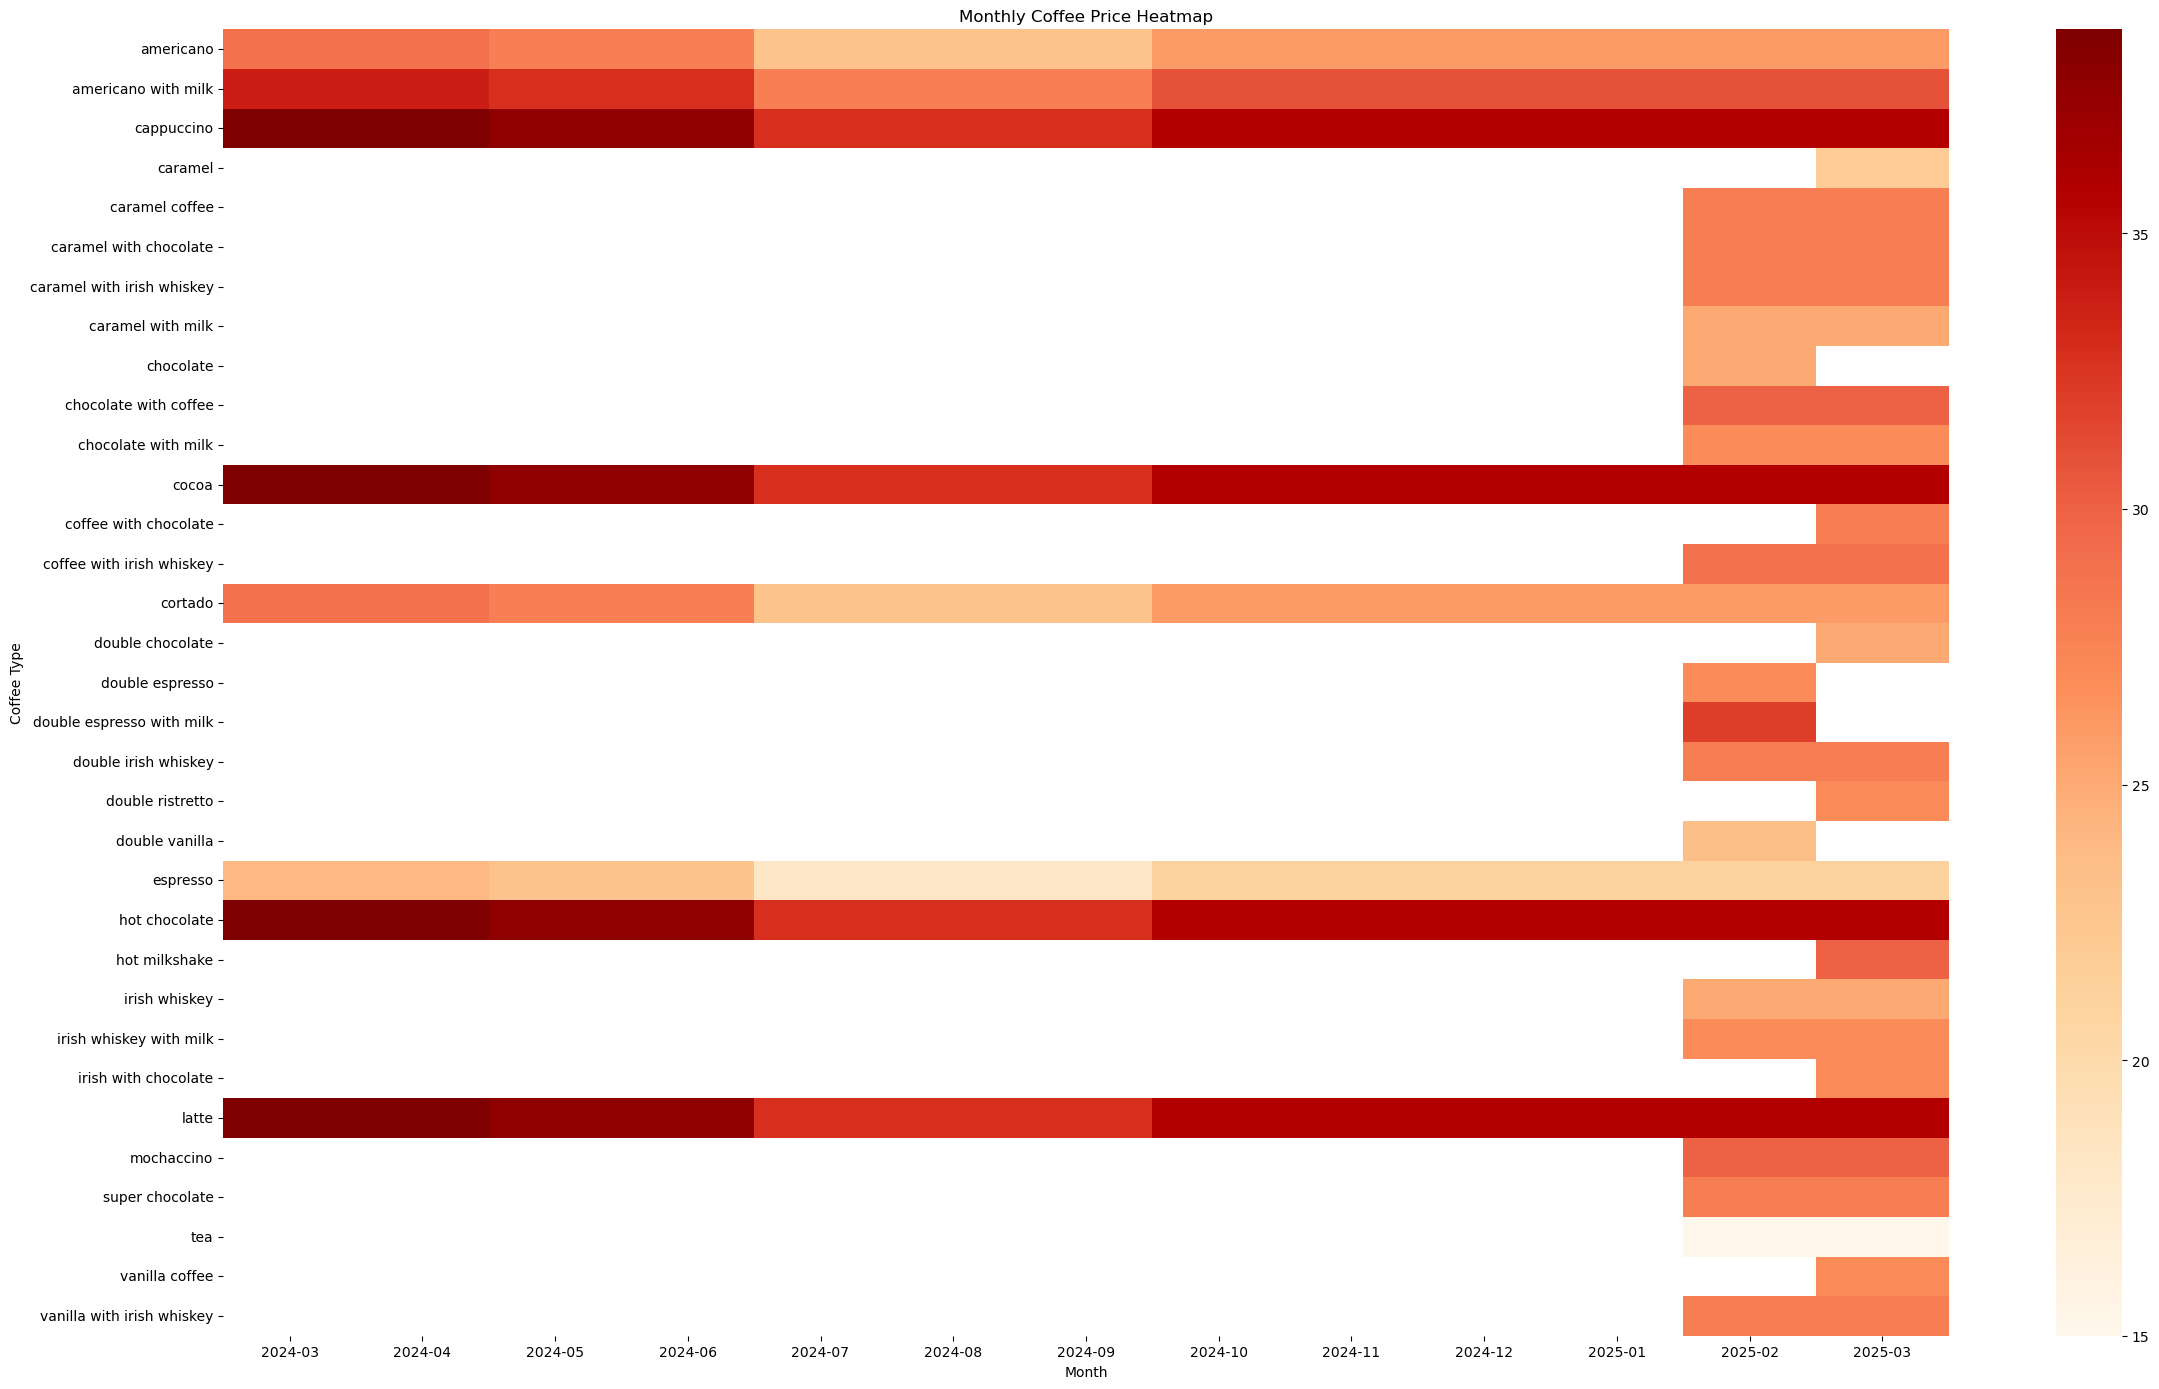

In [25]:
def monthly_median_price(df):
    # Ensure datetime column is proper dtype
    df = df.copy()
    df['datetime'] = pandas.to_datetime(df['datetime'])
    
    # Extract month as Period[M]
    df['month'] = df['datetime'].dt.to_period('M')
    
    # Group by month and coffee_name, compute median price
    pivot = (
        df.groupby(['month', 'coffee_name'])['money']
          .median()
          .unstack(fill_value=None)
          #.reset_index()
          .sort_values(by='month')
    )
    
    return pivot

median_price_pivot = monthly_median_price(data)
html_table = median_price_pivot.to_html()
display(HTML(f"<div style='overflow-x: auto; max-height:400px;'>{html_table}</div>"))

# Transpose for heatmap
monthly_price_heatmap = median_price_pivot.T

# Convert Period index to string for display
monthly_price_heatmap.columns = monthly_price_heatmap.columns.astype(str)

# Plot heatmap
pyplot.figure(figsize=(24, 14))
seaborn.heatmap(monthly_price_heatmap, cmap='OrRd', fmt=".2f")
pyplot.title("Monthly Coffee Price Heatmap")
pyplot.xlabel("Month")
pyplot.ylabel("Coffee Type")
pyplot.tight_layout()
pyplot.show()

In [26]:
total_money_per_coffee_name = (
    data.groupby('coffee_name')['money']
    .sum()
    .reset_index()
    .rename(columns={'money': 'total_money'})
    .sort_values(by='total_money', ascending=False)
)

print(total_money_per_coffee_name)

                   coffee_name  total_money
27                       latte     28658.30
1          americano with milk     26369.12
2                   cappuccino     18514.14
0                    americano     15437.26
22               hot chocolate     10172.46
11                       cocoa      8678.16
14                     cortado      7534.86
21                    espresso      3187.28
24               irish whiskey       525.00
13   coffee with irish whiskey       464.00
25     irish whiskey with milk       405.00
18        double irish whiskey       336.00
10         chocolate with milk       324.00
30                         tea       240.00
6   caramel with irish whiskey       224.00
29             super chocolate       168.00
9        chocolate with coffee       150.00
28                  mochaccino       150.00
26        irish with chocolate       135.00
5       caramel with chocolate       112.00
32  vanilla with irish whiskey        84.00
7            caramel with milk  

,month,total_money_month,total_cups_month,median_price_month
0,2024-03,7050.20,206,33.80
1,2024-04,6720.56,196,33.80
2,2024-05,9063.42,267,37.72
3,2024-06,7758.76,227,37.72
4,2024-07,6915.94,237,27.92
5,2024-08,7613.84,272,27.92
6,2024-09,9988.64,344,27.92
7,2024-10,13891.16,426,35.76
8,2024-11,8590.54,259,35.76
9,2024-12,8237.74,259,35.76


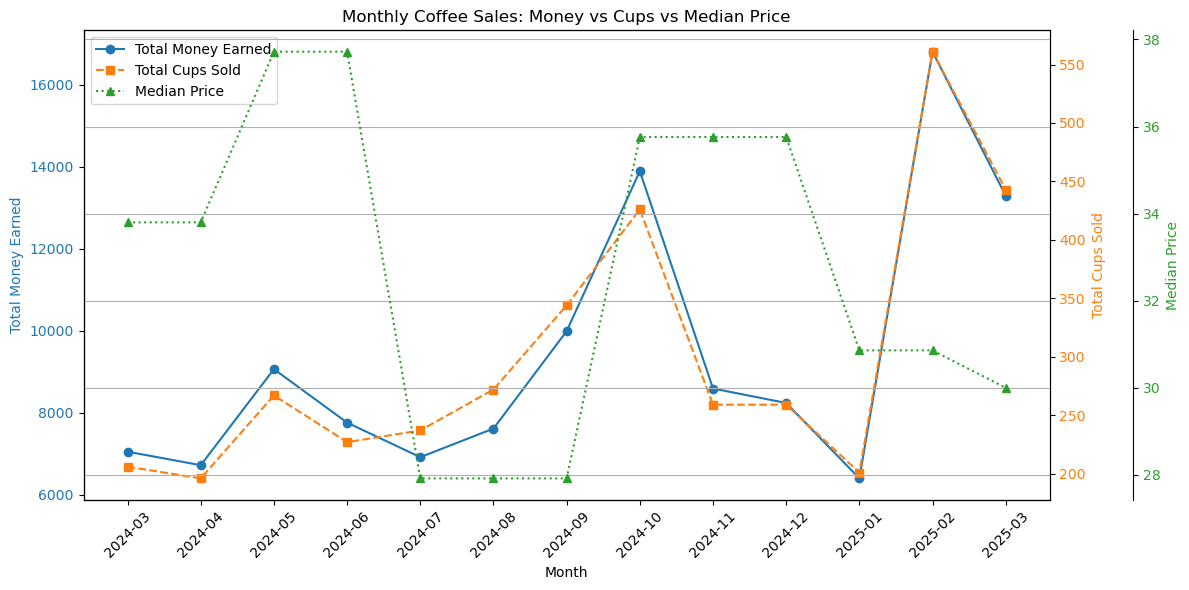

In [27]:
def monthly_total_price(df):
    # Ensure date column is proper dtype
    df = df.copy()
    df['date'] = pandas.to_datetime(df['date'])
    
    # Extract month as Period[M]
    df['month'] = df['date'].dt.to_period('M')
    
    # Group by month, compute median price
    pivot = (
        df.groupby('month')
          .agg(total_money_month=('money', 'sum'),
               total_cups_month=('money', 'count'),
               median_price_month=('money', 'median')
              )
          .reset_index()
          .sort_values(by='month')
    )
    
    return pivot

monthly_total_pivot = monthly_total_price(data)
html_table = monthly_total_pivot.to_html()
display(HTML(f"<div style='overflow-x: auto; max-height:400px;'>{html_table}</div>"))

months = monthly_total_pivot['month'].astype(str)

fig, ax1 = pyplot.subplots(figsize=(12, 6))

# Left axis: total money
ax1.plot(months, monthly_total_pivot['total_money_month'],
         marker='o', linestyle='-', color='tab:blue', label='Total Money Earned')
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Money Earned", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(range(len(months)))
ax1.set_xticklabels(months, rotation=45)   

# Right axis #1: total cups
ax2 = ax1.twinx()
ax2.plot(months, monthly_total_pivot['total_cups_month'],
         marker='s', linestyle='--', color='tab:orange', label='Total Cups Sold')
ax2.set_ylabel("Total Cups Sold", color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Right axis #2: median price (offset outward so it doesn’t overlap with cups axis)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # push it outward
ax3.plot(months, monthly_total_pivot['median_price_month'],
         marker='^', linestyle=':', color='tab:green', label='Median Price')
ax3.set_ylabel("Median Price", color='tab:green')
ax3.tick_params(axis='y', labelcolor='tab:green')

# Title
pyplot.title("Monthly Coffee Sales: Money vs Cups vs Median Price")

# Combine legends from all axes
lines, labels = [], []
for ax in [ax1, ax2, ax3]:
    line, label = ax.get_legend_handles_labels()
    lines += line
    labels += label
ax1.legend(lines, labels, loc='upper left')

pyplot.grid(True)
pyplot.tight_layout()
pyplot.show()

,month,coffee_name,total_money_month,total_cups_month,median_price_month
0,2024-03,americano,1044.80,36,28.90
8,2024-04,americano,1001.94,35,28.90
16,2024-05,americano,1348.80,48,27.92
24,2024-06,americano,390.88,14,27.92
32,2024-07,americano,858.12,36,23.02
40,2024-08,americano,851.74,37,23.02
48,2024-09,americano,739.58,32,23.02
56,2024-10,americano,1142.24,44,25.96
64,2024-11,americano,649.00,25,25.96
72,2024-12,americano,700.92,27,25.96


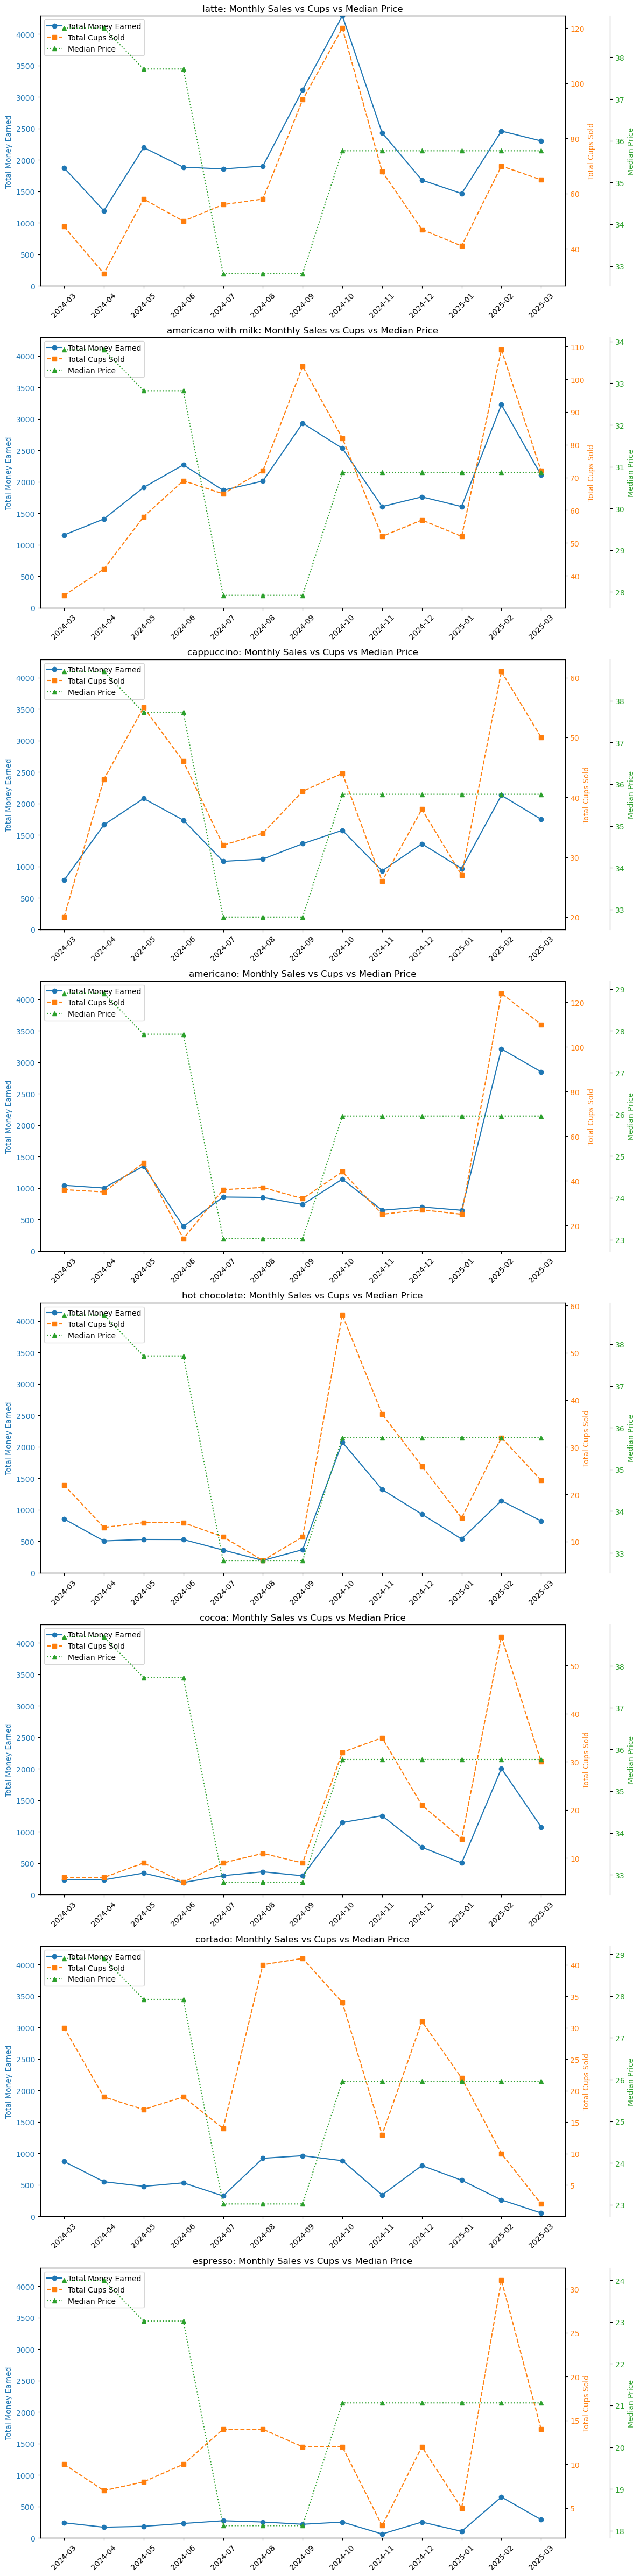

In [28]:
def monthly_total_price_per_coffee(df):
    df = df.copy()
    df['date'] = pandas.to_datetime(df['date'])
    df['month'] = df['date'].dt.to_period('M')
    
    pivot = (
        df.groupby(['month', 'coffee_name'])
          .agg(total_money_month=('money', 'sum'),
               total_cups_month=('money', 'count'),
               median_price_month=('money', 'median'))
          .reset_index()
          .sort_values(by=['coffee_name','month'])
    )
    return pivot

monthly_total_pivot = monthly_total_price_per_coffee(data)
html_table = monthly_total_pivot.to_html()
display(HTML(f"<div style='overflow-x: auto; max-height:400px;'>{html_table}</div>"))

months = monthly_total_pivot['month'].astype(str).unique()
coffee_types = numpy.array(
    [
        'latte', 
        'americano with milk', 
        'cappuccino',
        'americano',
        'hot chocolate',
        'cocoa',
        'cortado',
        'espresso'
    ]
)

# Find global max for money axis so all plots share the same scale
max_money = monthly_total_pivot['total_money_month'].max()

# Create one subplot per coffee type
fig, axes = pyplot.subplots(len(coffee_types), 1, figsize=(12, 6*len(coffee_types)))

if len(coffee_types) == 1:
    axes = [axes]  # ensure iterable if only one coffee type

for ax, coffee in zip(axes, coffee_types):
    df_coffee = monthly_total_pivot[monthly_total_pivot['coffee_name'] == coffee]
    months_coffee = df_coffee['month'].astype(str)
    
    # Left axis: total money
    ax1 = ax
    ax1.plot(months_coffee, df_coffee['total_money_month'],
             marker='o', linestyle='-', color='tab:blue', label='Total Money Earned')
    ax1.set_ylabel("Total Money Earned", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_ylim(0, max_money)  # fix same scale for all coffee types
    ax1.set_xticks(range(len(months_coffee)))
    ax1.set_xticklabels(months_coffee, rotation=45)
    
    # Right axis #1: total cups
    ax2 = ax1.twinx()
    ax2.plot(months_coffee, df_coffee['total_cups_month'],
             marker='s', linestyle='--', color='tab:orange', label='Total Cups Sold')
    ax2.set_ylabel("Total Cups Sold", color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    
    # Right axis #2: median price
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(months_coffee, df_coffee['median_price_month'],
             marker='^', linestyle=':', color='tab:green', label='Median Price')
    ax3.set_ylabel("Median Price", color='tab:green')
    ax3.tick_params(axis='y', labelcolor='tab:green')
    
    # Title per coffee type
    ax1.set_title(f"{coffee}: Monthly Sales vs Cups vs Median Price")
    
    # Combine legends
    lines, labels = [], []
    for axis in [ax1, ax2, ax3]:
        l, lab = axis.get_legend_handles_labels()
        lines += l
        labels += lab
    ax1.legend(lines, labels, loc='upper left')

pyplot.tight_layout()
pyplot.show()


americano: 13 months present in data -> [Period('2024-03', 'M'), Period('2024-04', 'M'), Period('2024-05', 'M'), Period('2024-06', 'M'), Period('2024-07', 'M'), Period('2024-08', 'M'), Period('2024-09', 'M'), Period('2024-10', 'M'), Period('2024-11', 'M'), Period('2024-12', 'M'), Period('2025-01', 'M'), Period('2025-02', 'M'), Period('2025-03', 'M')]


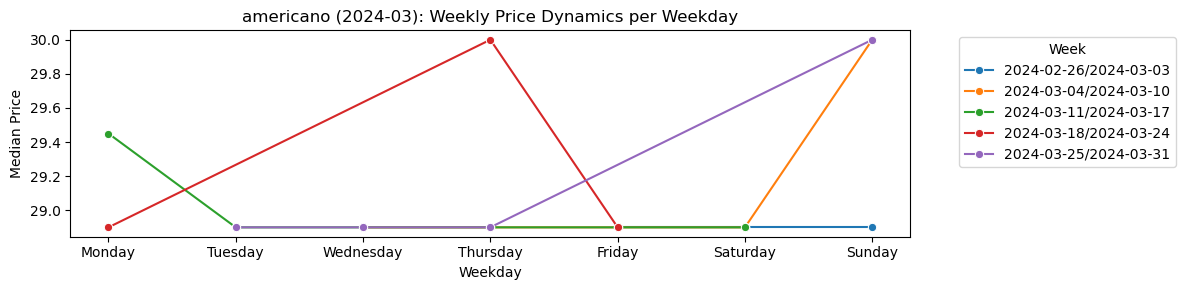

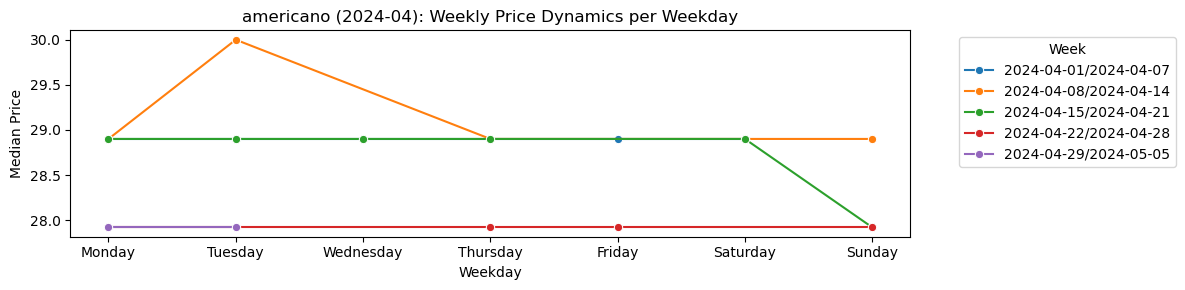

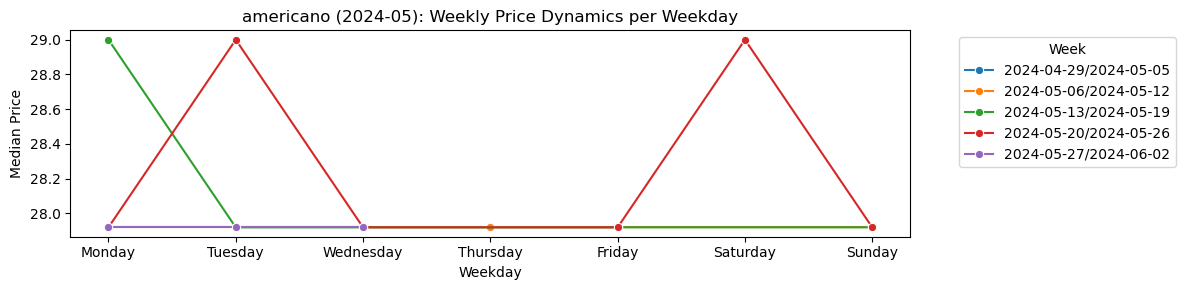

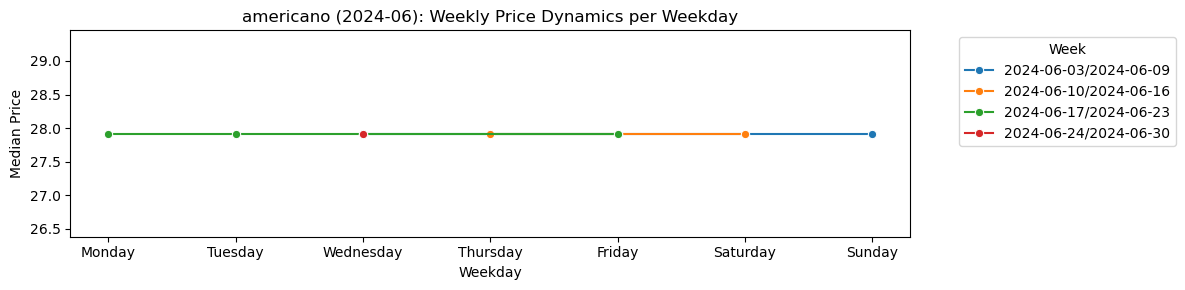

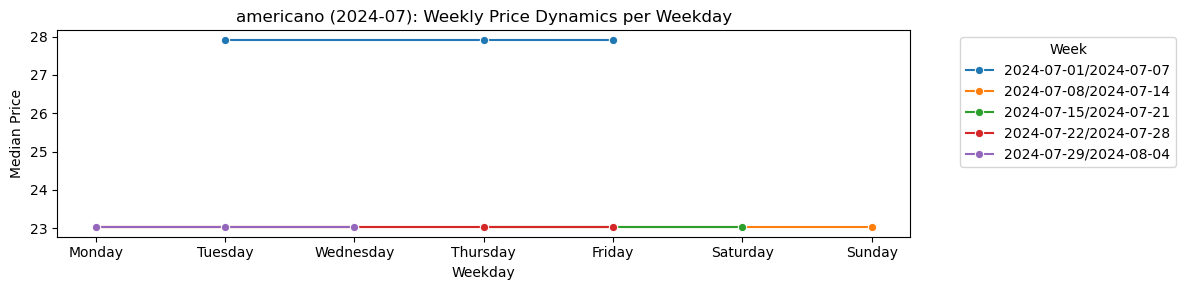

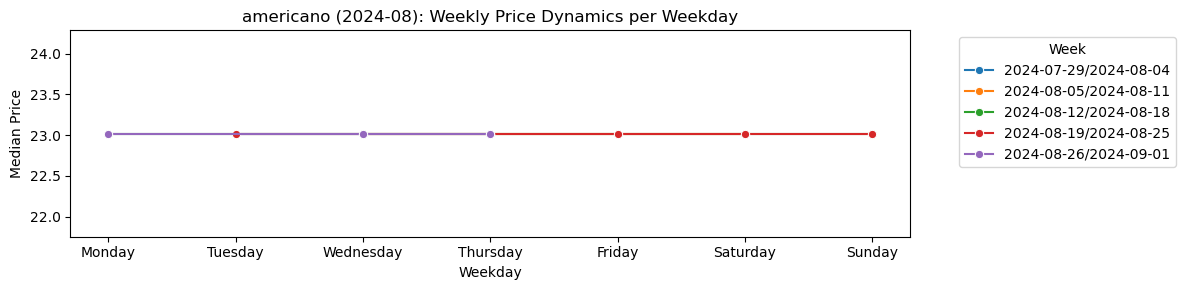

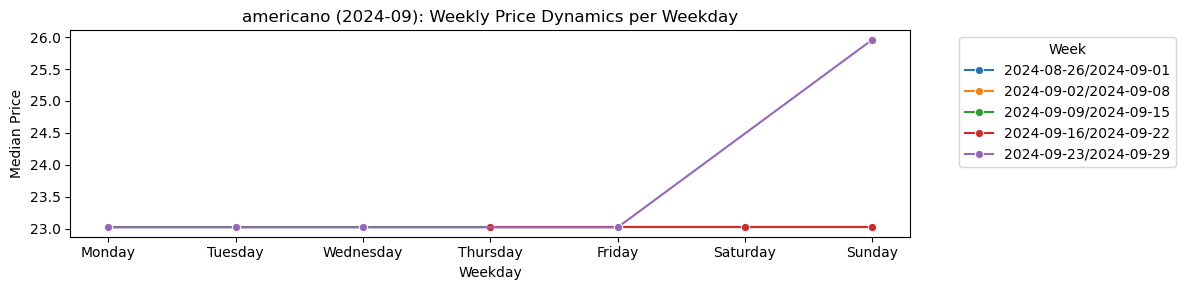

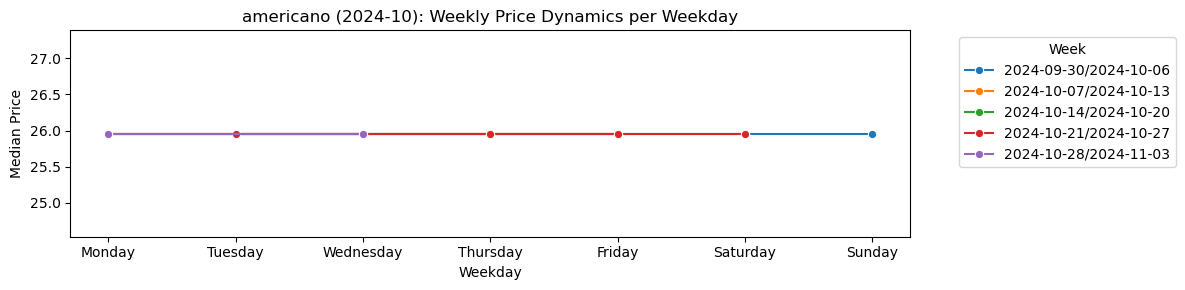

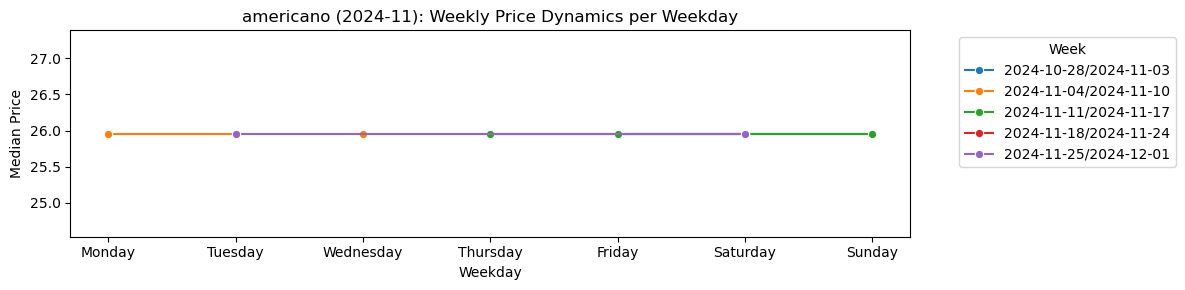

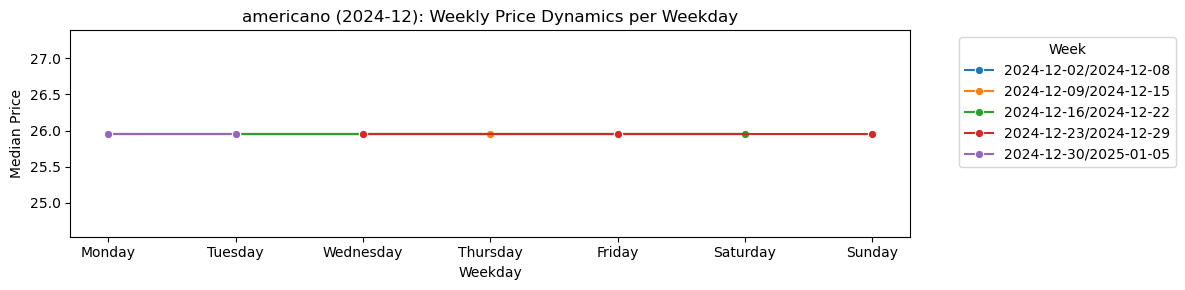

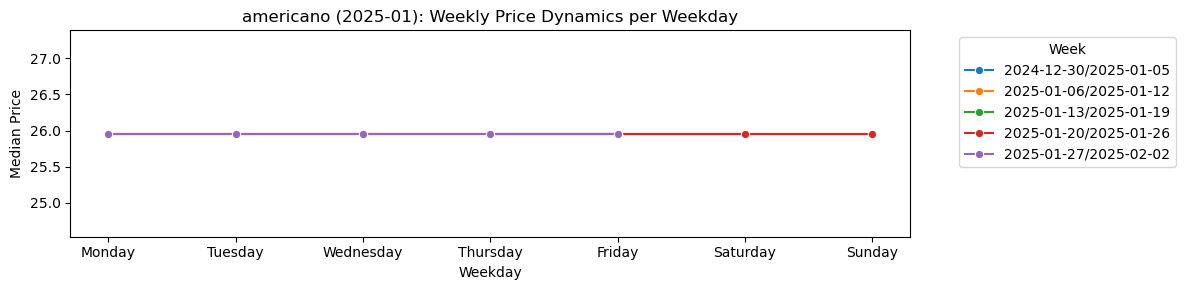

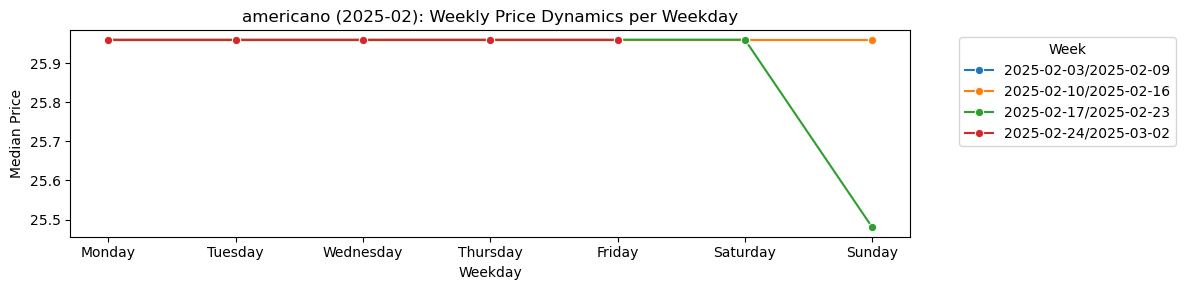

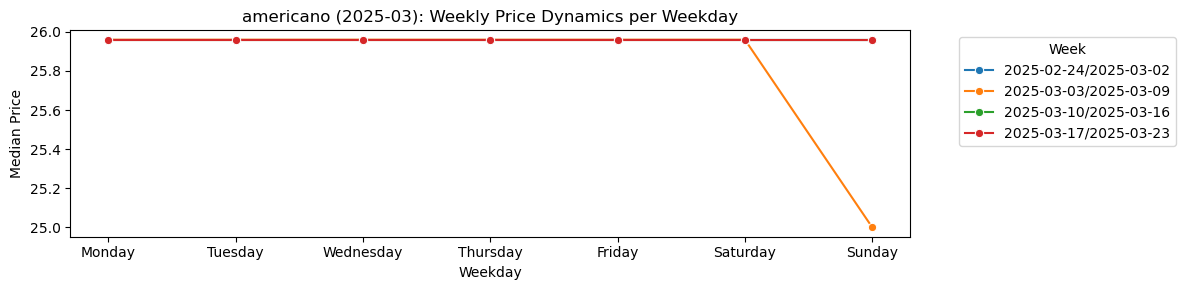

In [29]:
def monthly_weekly_price_dynamics(df, coffee_name):
    df = df.copy()
    df['date'] = pandas.to_datetime(df['date'])
    df['month'] = df['date'].dt.to_period('M')
    df['week'] = df['date'].dt.to_period('W')
    df['weekday'] = df['date'].dt.day_name()
    
    # Filter for the specific coffee type
    df = df[df['coffee_name'] == coffee_name]
    
    # Group by month, week, weekday
    grouped = (
        df.groupby(['month','week','weekday'])['money']
          .median()
          .reset_index()
    )
    
    # Ensure weekdays are ordered Mon–Sun
    weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    grouped['weekday'] = pandas.Categorical(grouped['weekday'], categories=weekday_order, ordered=True)
    
    # Identify months present
    months = grouped['month'].unique()
    print(f"{coffee_name}: {len(months)} months present in data -> {list(months)}")
    
    # Plot per month
    for month in months:
        df_month = grouped[grouped['month'] == month]
        
        pyplot.figure(figsize=(12,3))
        seaborn.lineplot(data=df_month, x='weekday', y='money', hue='week', marker='o')
        pyplot.title(f"{coffee_name} ({month}): Weekly Price Dynamics per Weekday")
        pyplot.xlabel("Weekday")
        pyplot.ylabel("Median Price")
        pyplot.legend(title="Week", bbox_to_anchor=(1.05, 1), loc='upper left')
        pyplot.tight_layout()
        pyplot.show()

monthly_weekly_price_dynamics(data, coffee_name='americano')

americano with milk: 56 weeks present -> [Period('2024-02-26/2024-03-03', 'W-SUN'), Period('2024-03-04/2024-03-10', 'W-SUN'), Period('2024-03-11/2024-03-17', 'W-SUN'), Period('2024-03-18/2024-03-24', 'W-SUN'), Period('2024-03-25/2024-03-31', 'W-SUN'), Period('2024-04-01/2024-04-07', 'W-SUN'), Period('2024-04-08/2024-04-14', 'W-SUN'), Period('2024-04-15/2024-04-21', 'W-SUN'), Period('2024-04-22/2024-04-28', 'W-SUN'), Period('2024-04-29/2024-05-05', 'W-SUN'), Period('2024-05-06/2024-05-12', 'W-SUN'), Period('2024-05-13/2024-05-19', 'W-SUN'), Period('2024-05-20/2024-05-26', 'W-SUN'), Period('2024-05-27/2024-06-02', 'W-SUN'), Period('2024-06-03/2024-06-09', 'W-SUN'), Period('2024-06-10/2024-06-16', 'W-SUN'), Period('2024-06-17/2024-06-23', 'W-SUN'), Period('2024-06-24/2024-06-30', 'W-SUN'), Period('2024-07-01/2024-07-07', 'W-SUN'), Period('2024-07-08/2024-07-14', 'W-SUN'), Period('2024-07-15/2024-07-21', 'W-SUN'), Period('2024-07-22/2024-07-28', 'W-SUN'), Period('2024-07-29/2024-08-04', 'W

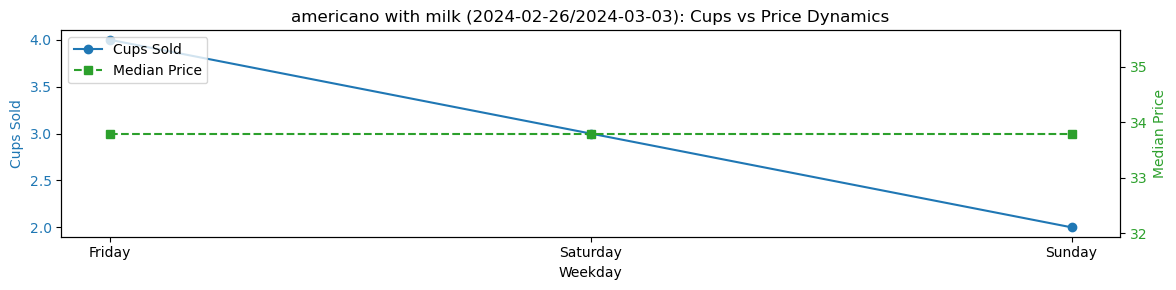

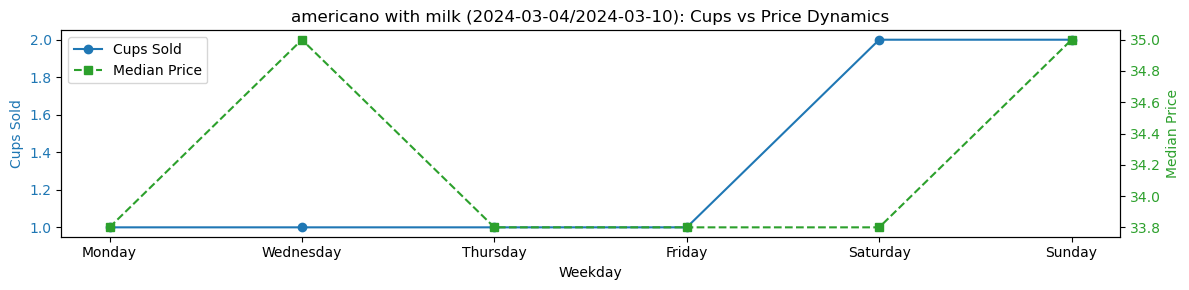

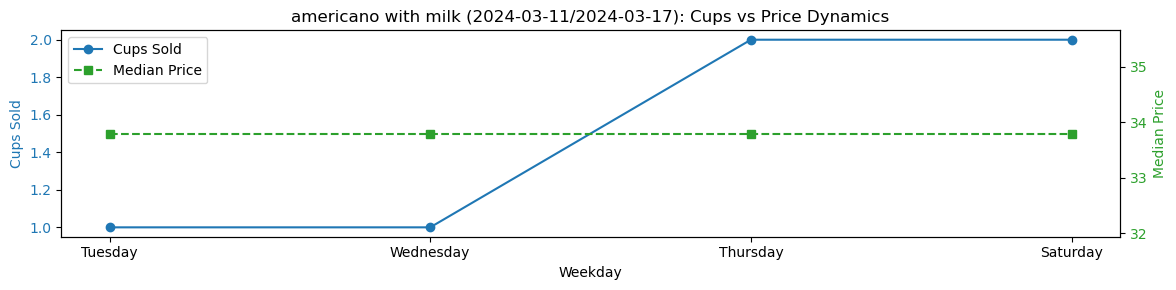

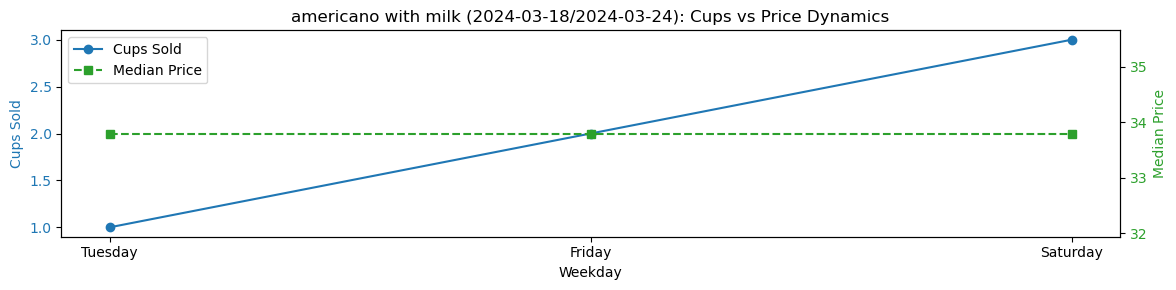

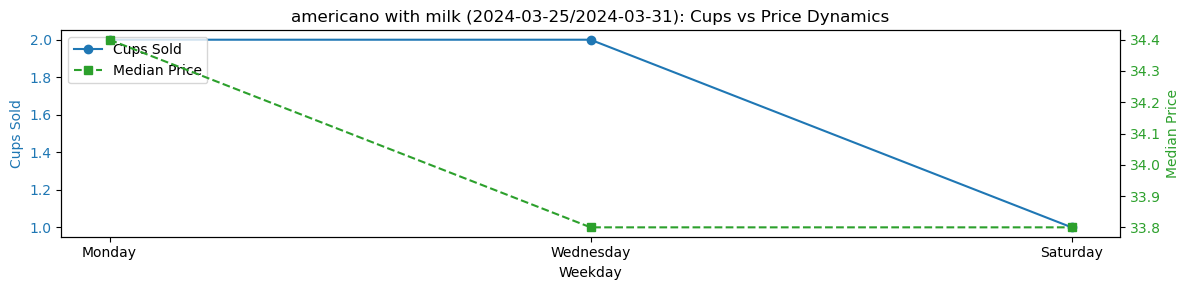

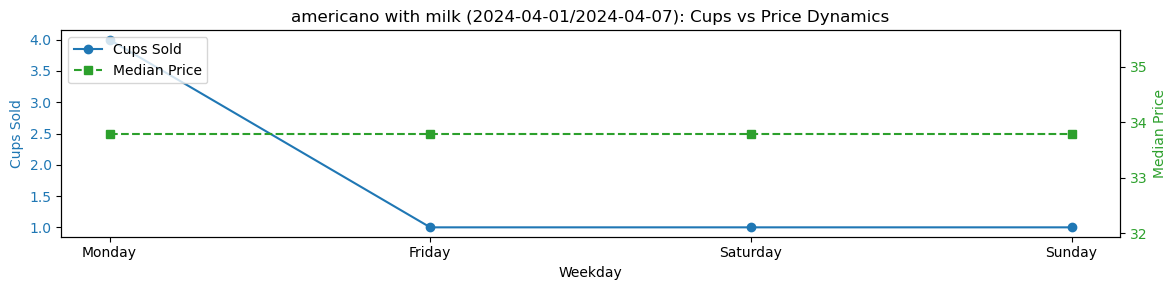

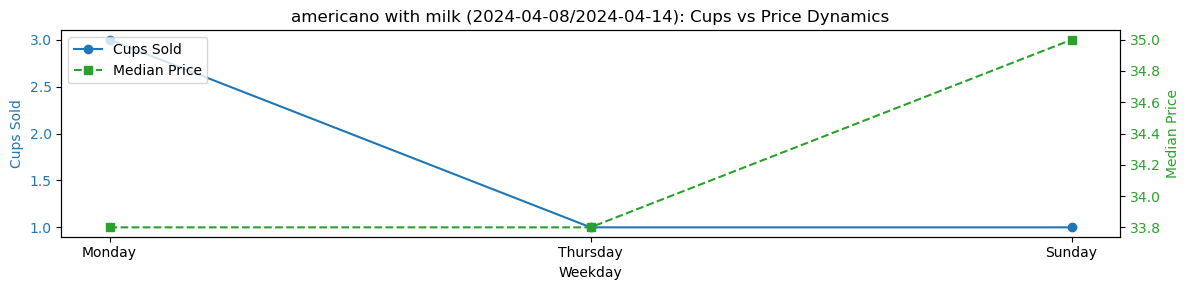

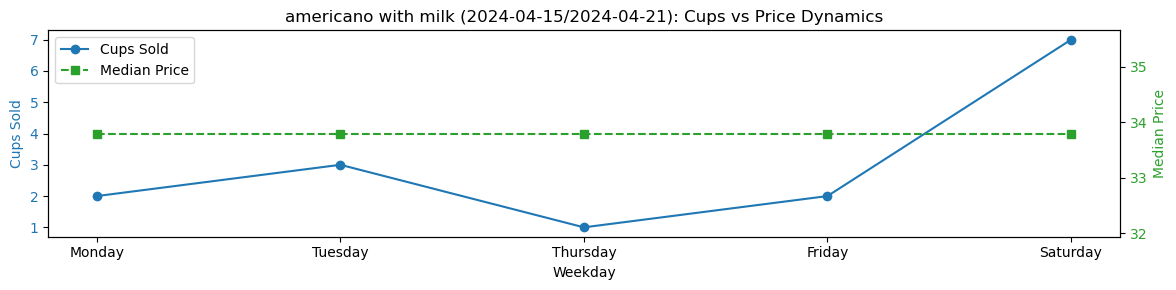

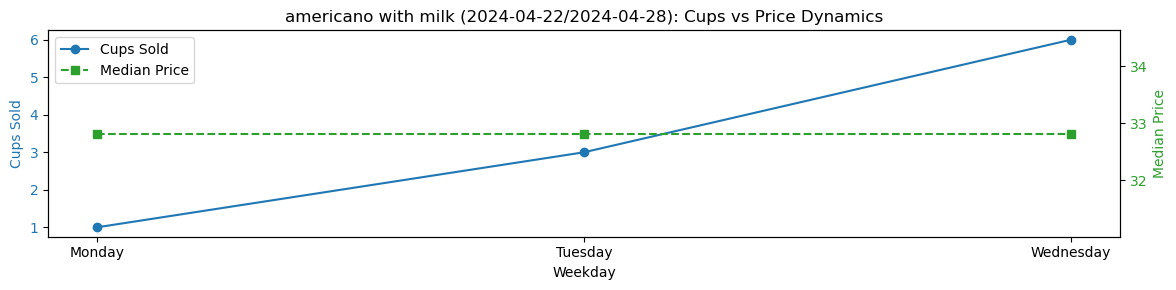

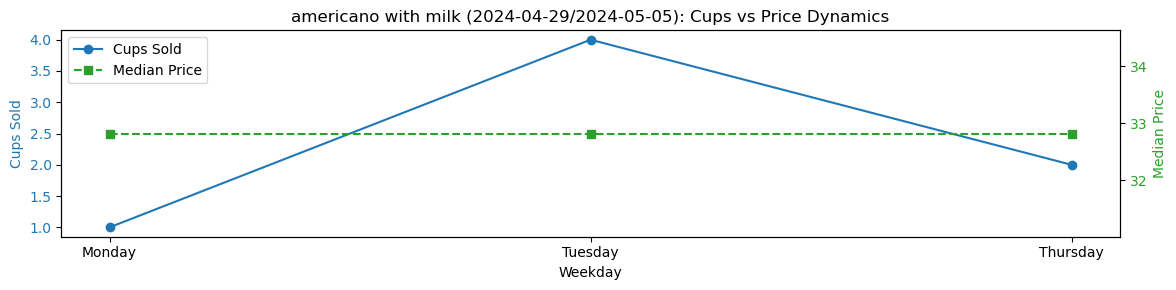

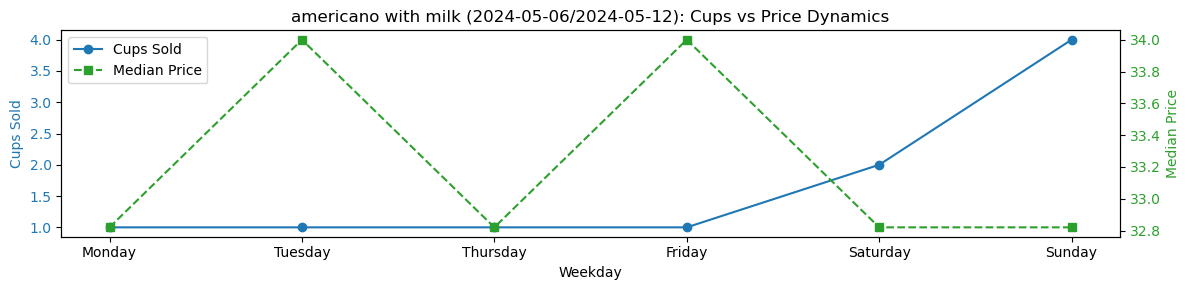

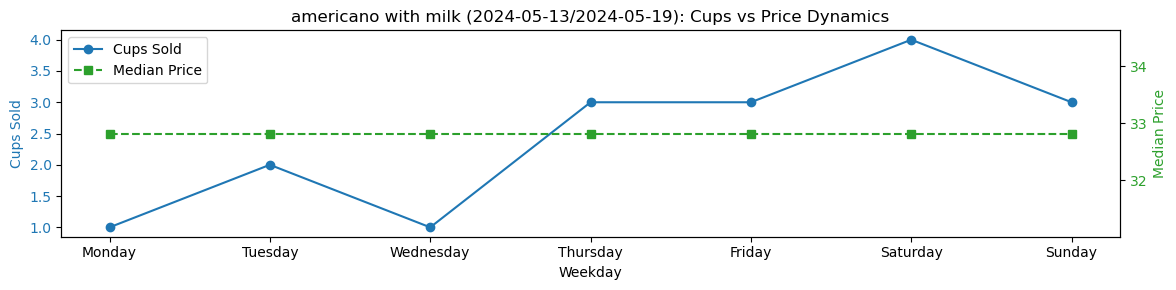

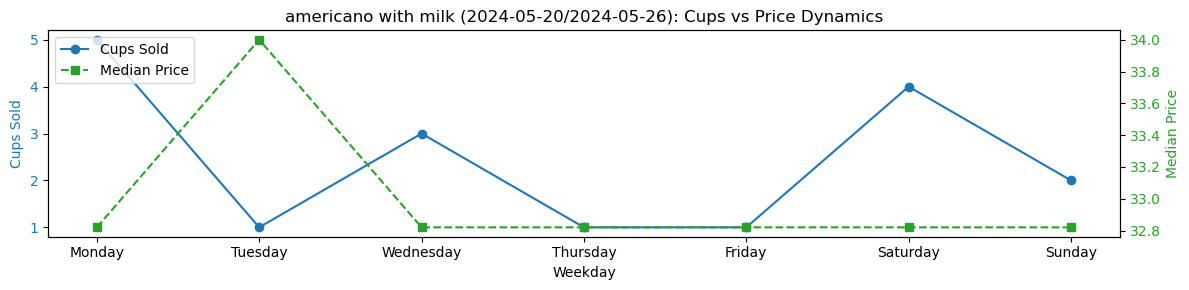

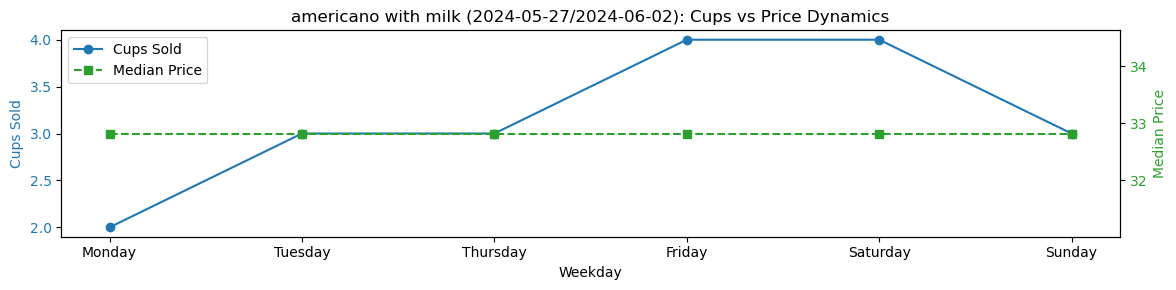

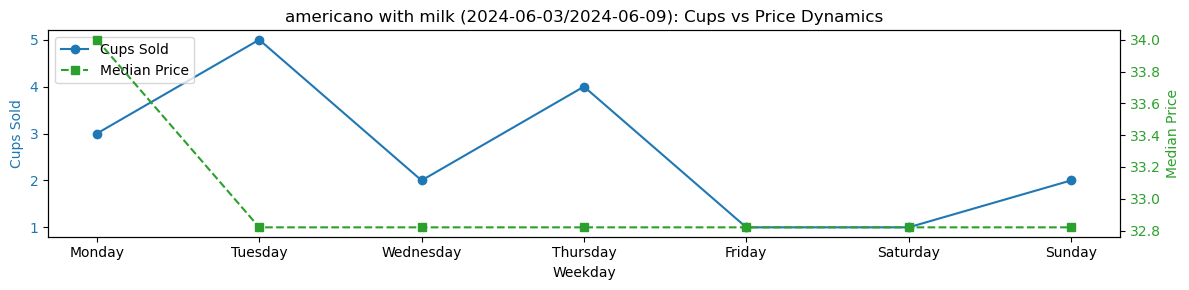

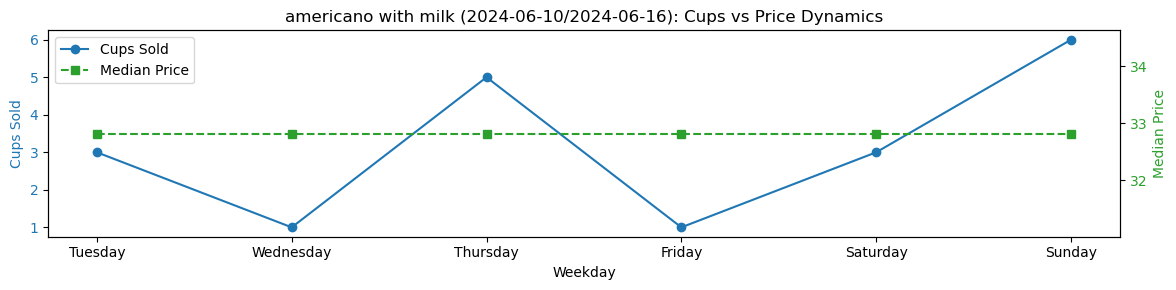

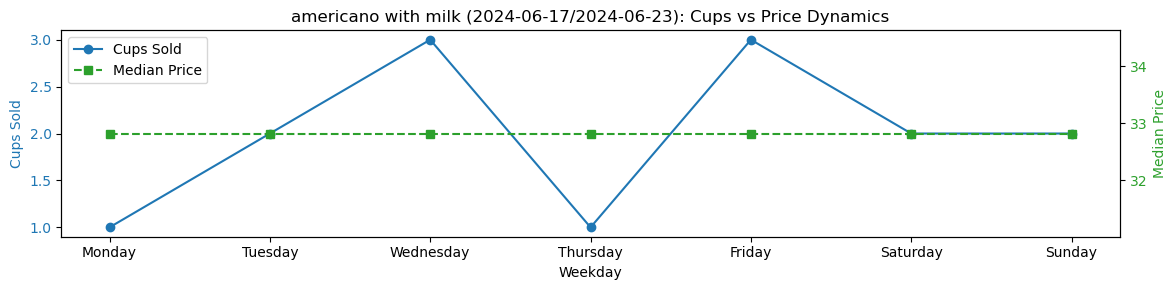

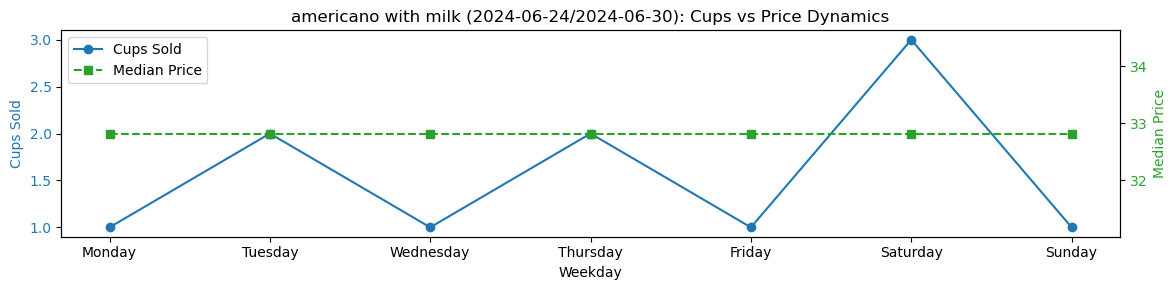

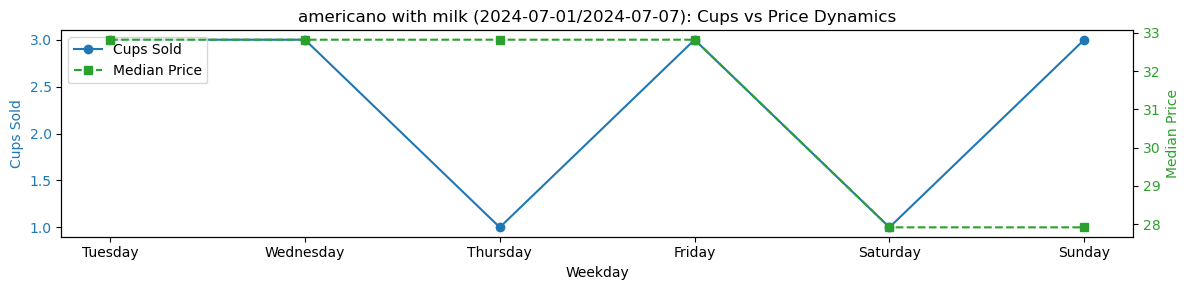

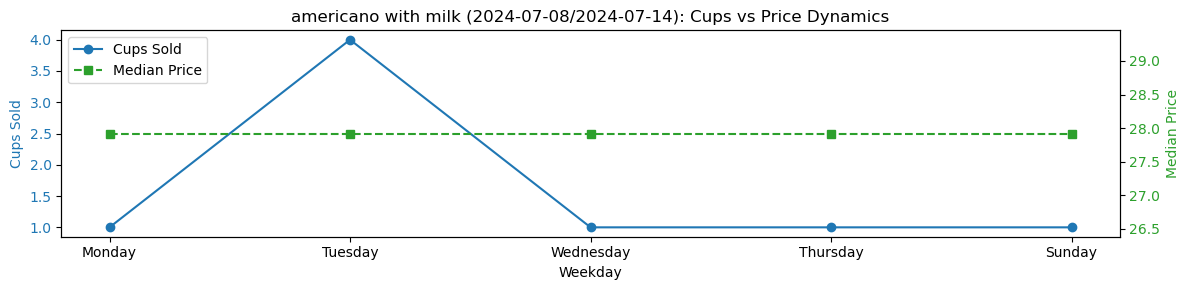

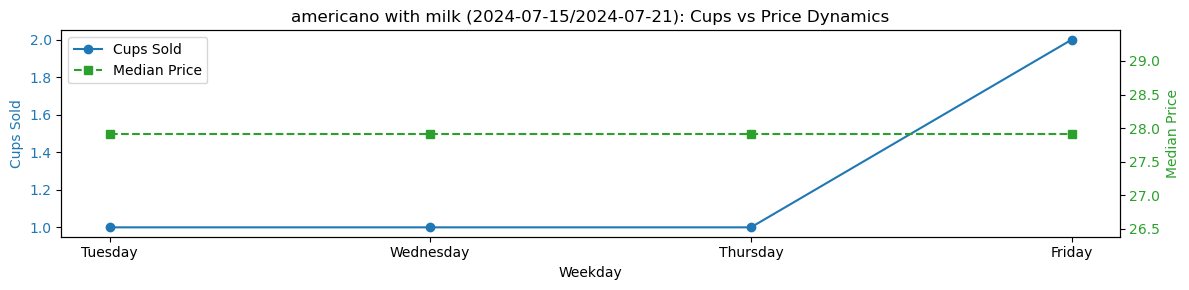

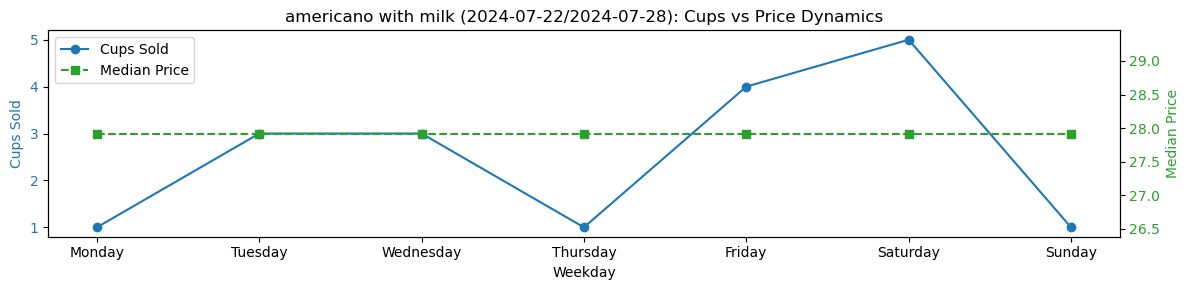

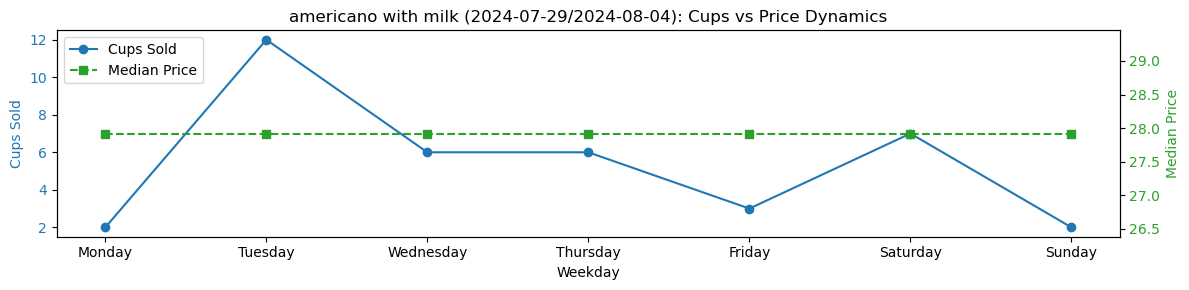

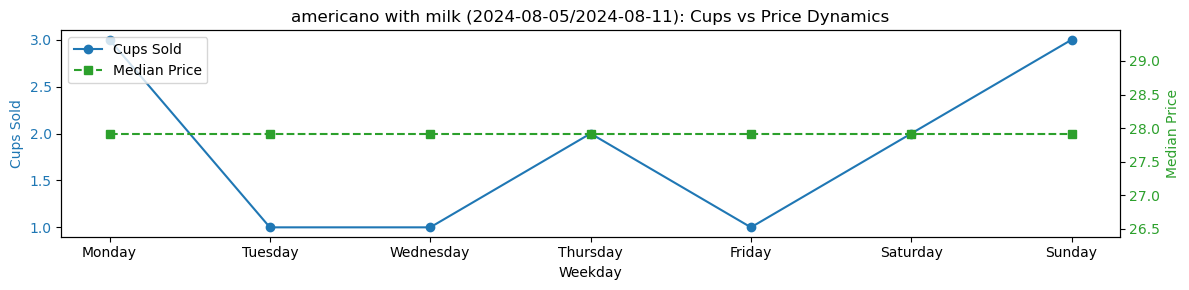

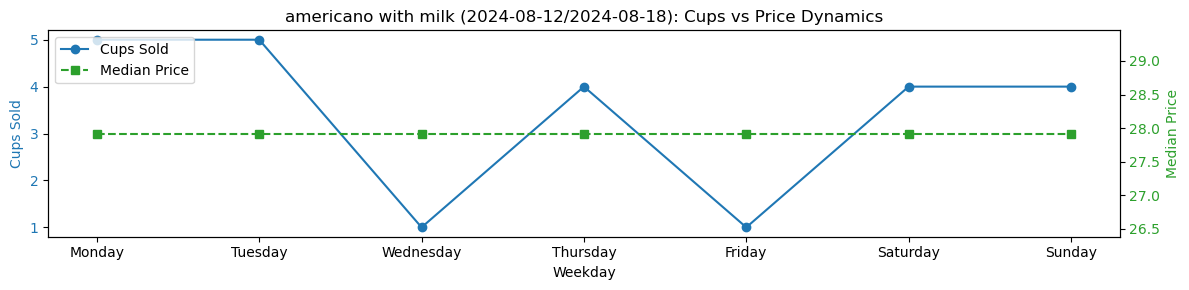

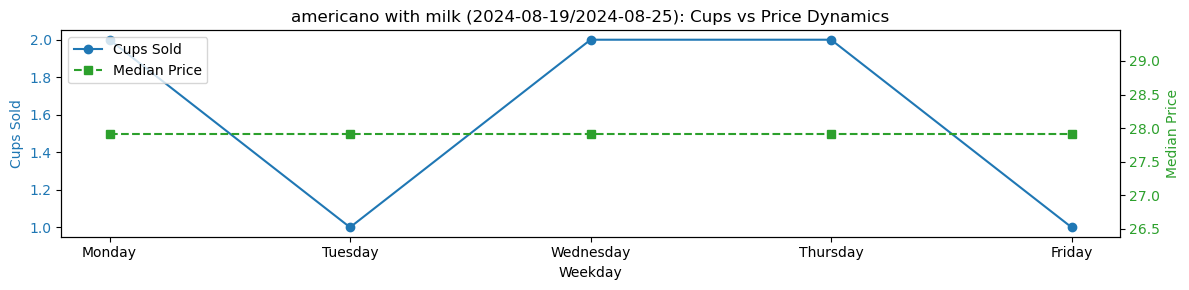

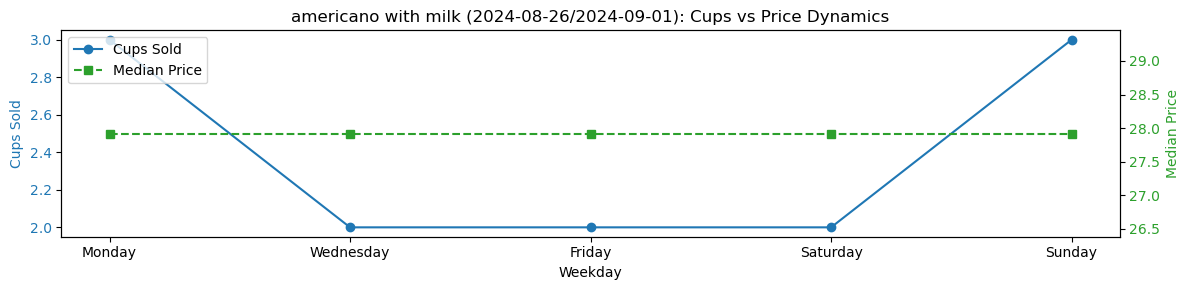

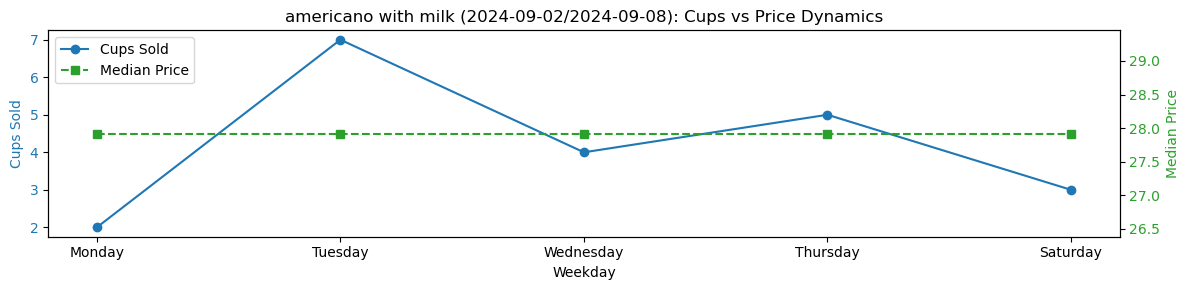

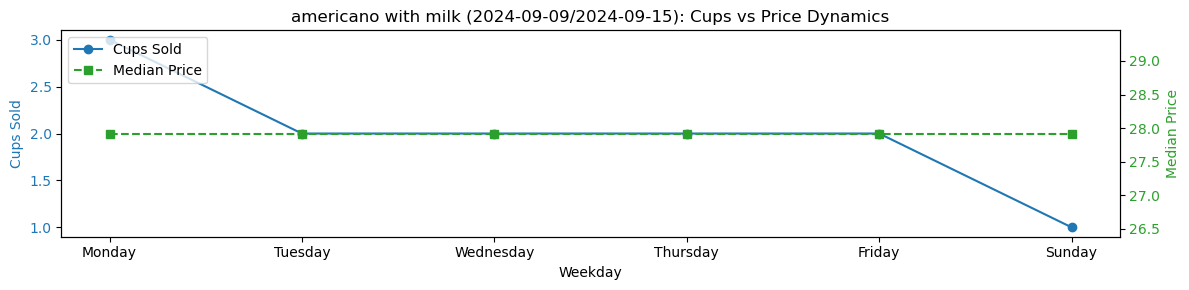

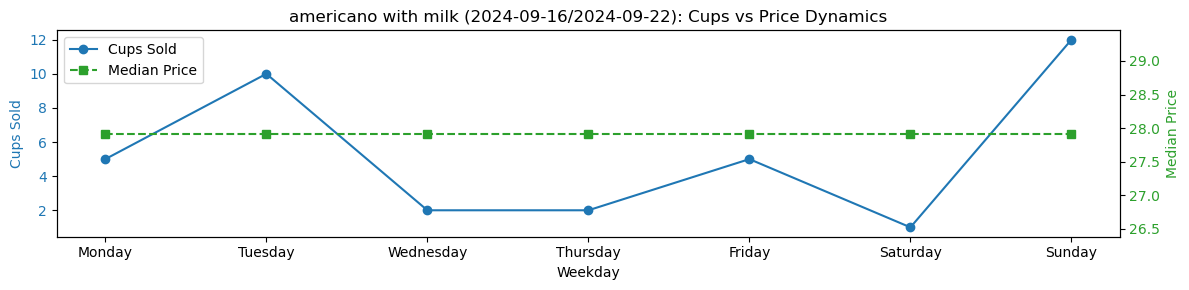

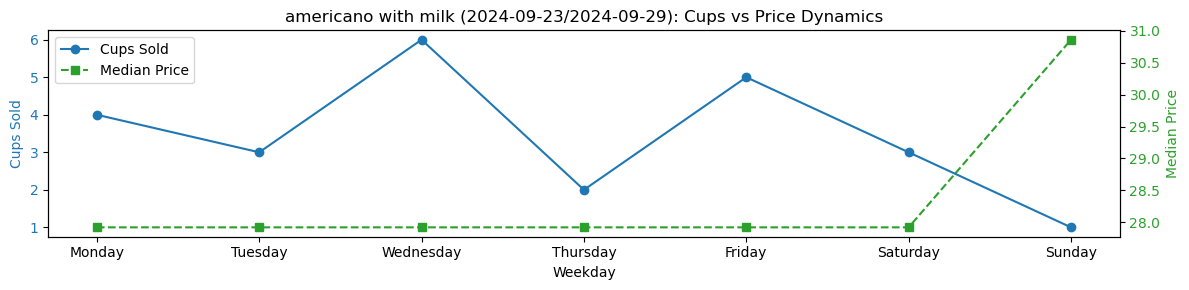

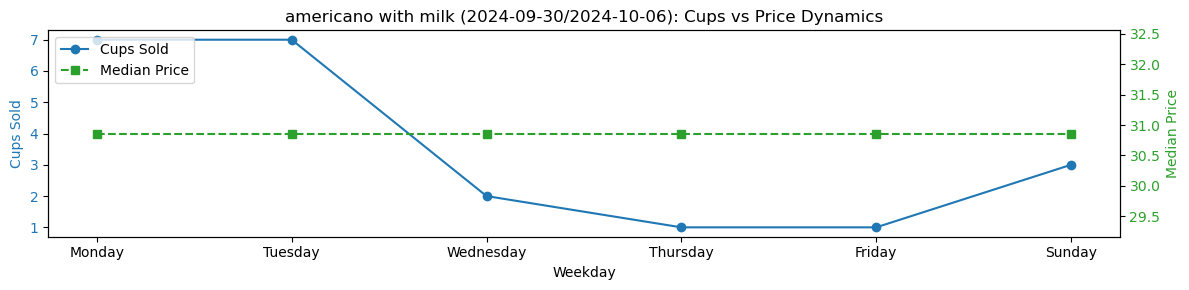

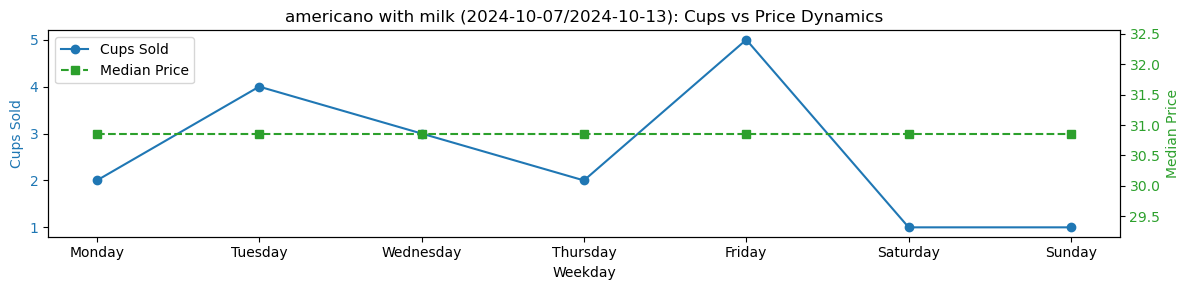

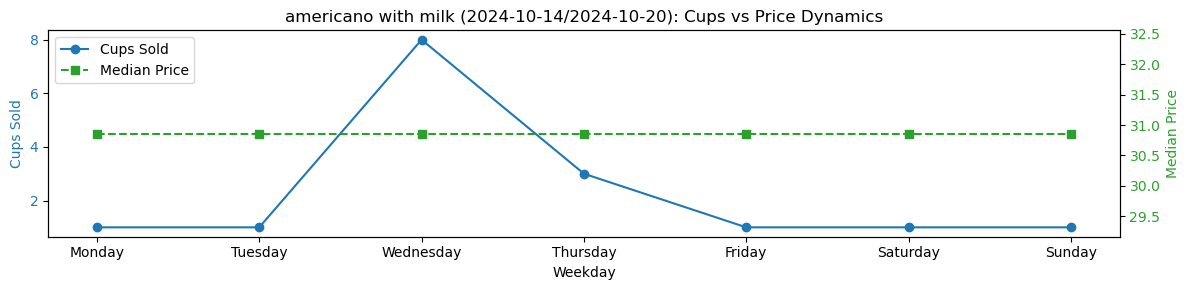

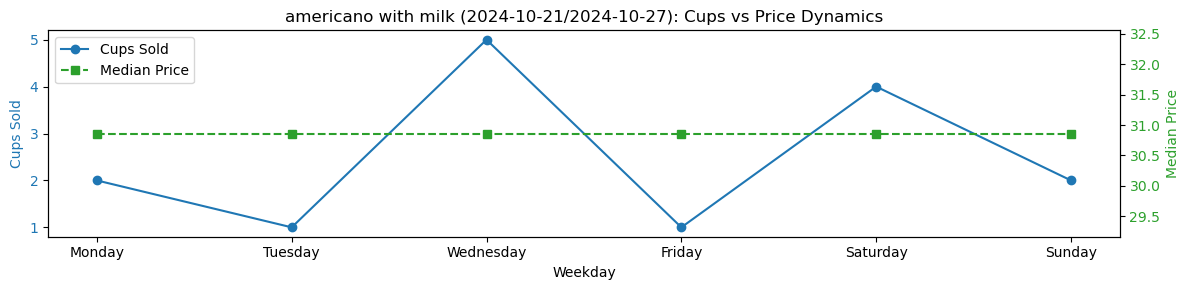

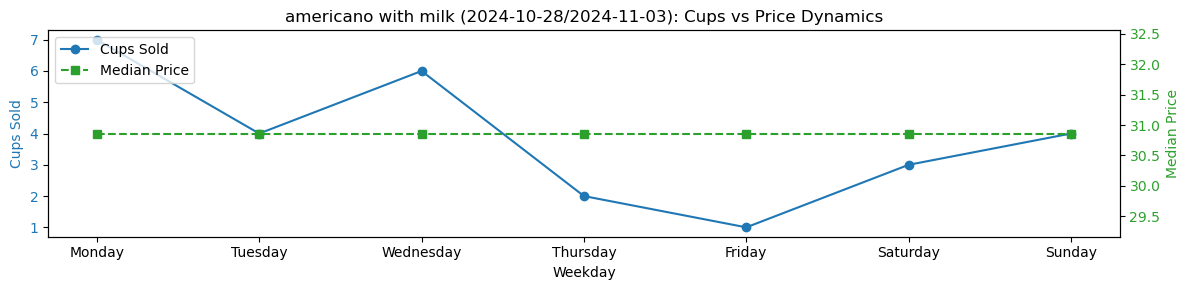

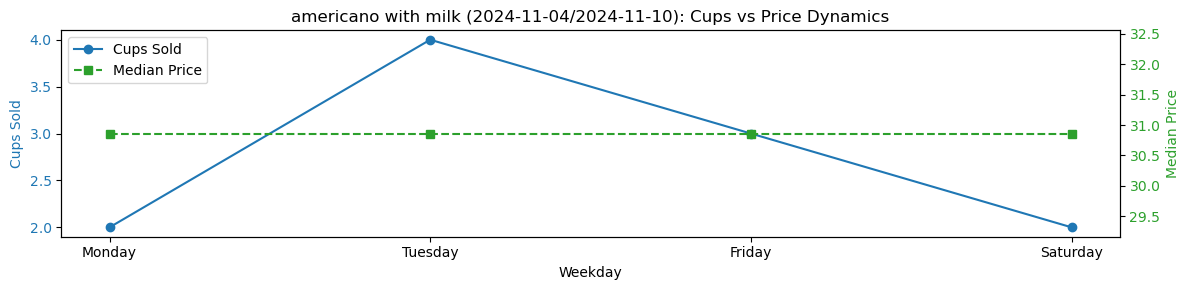

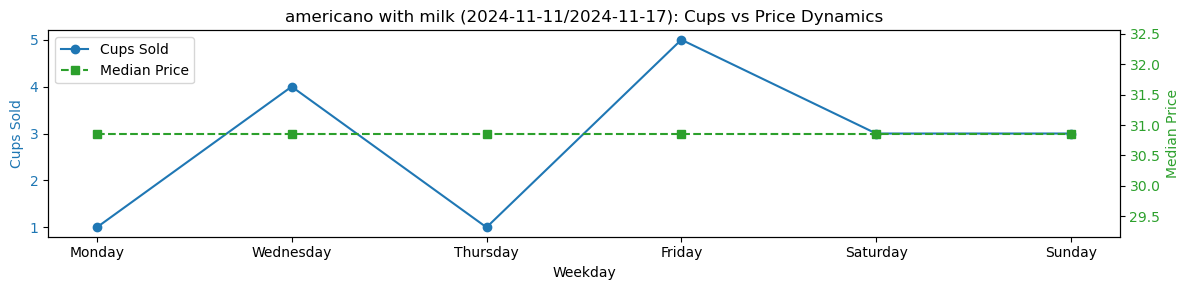

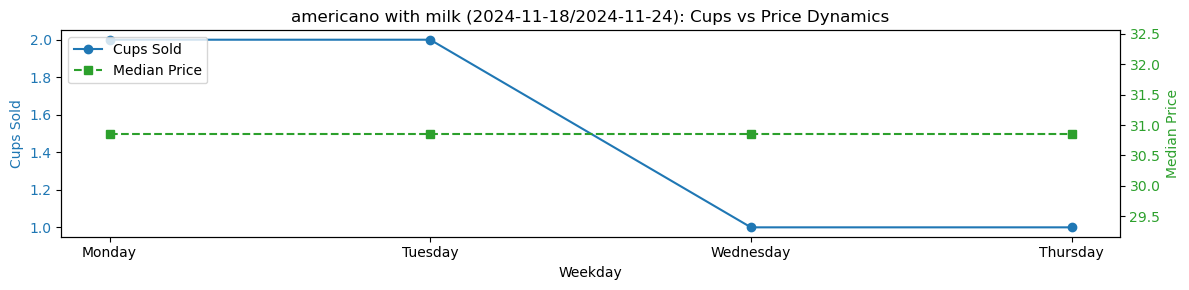

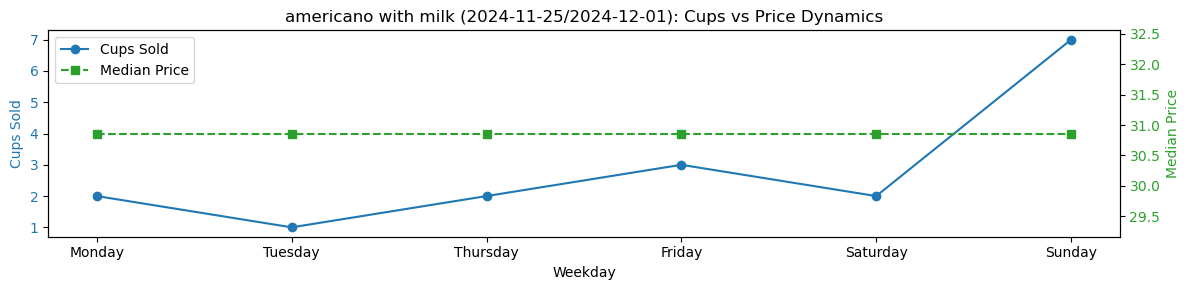

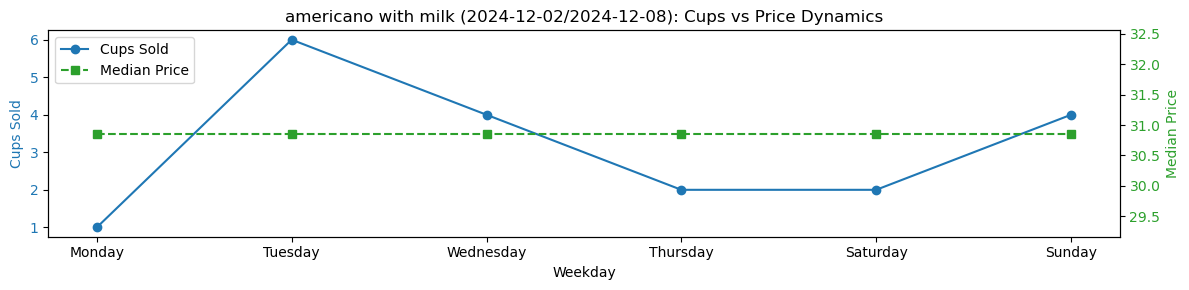

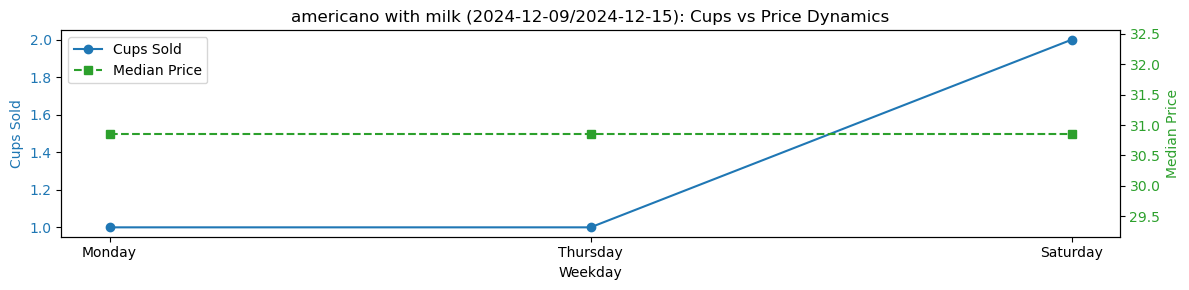

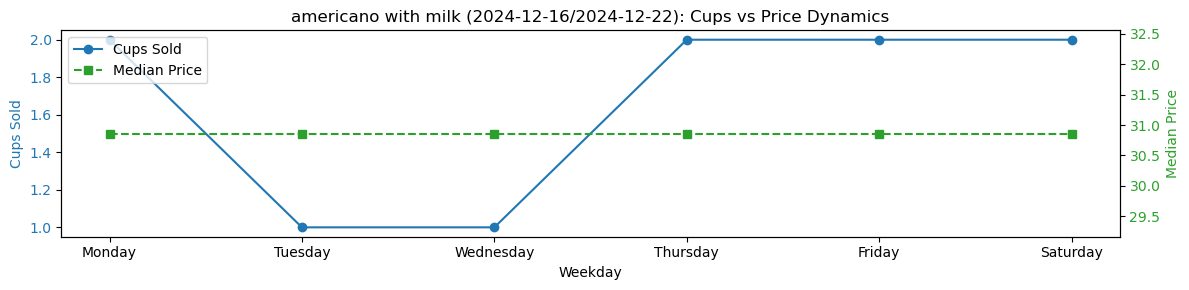

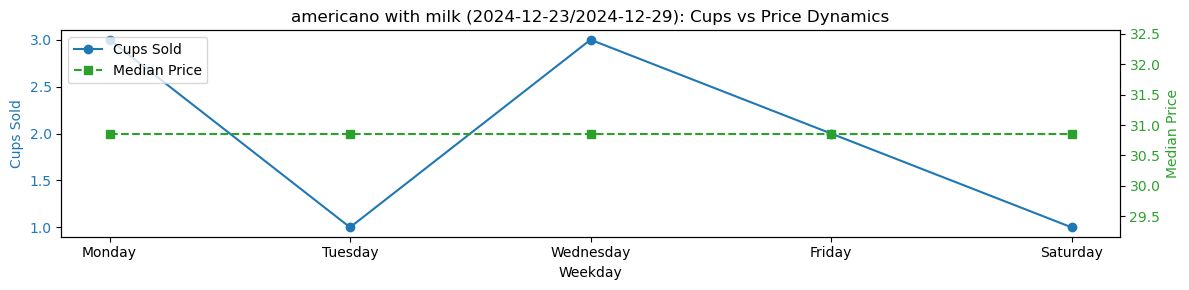

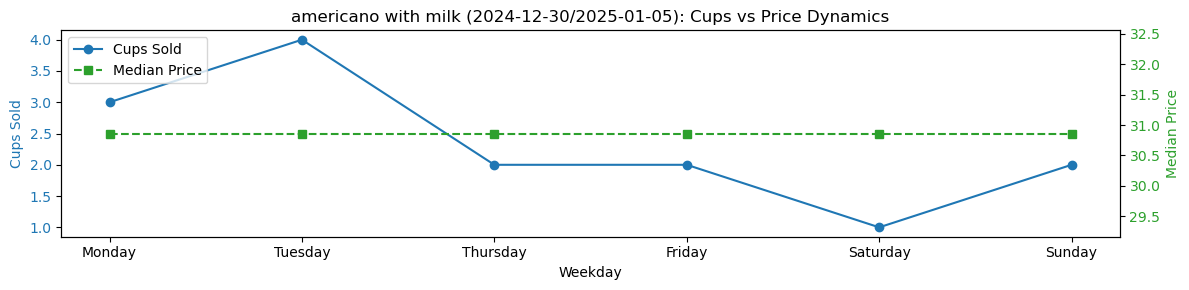

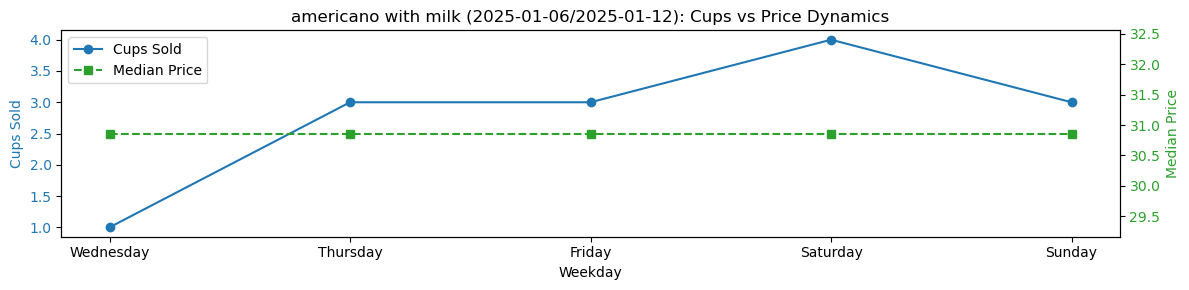

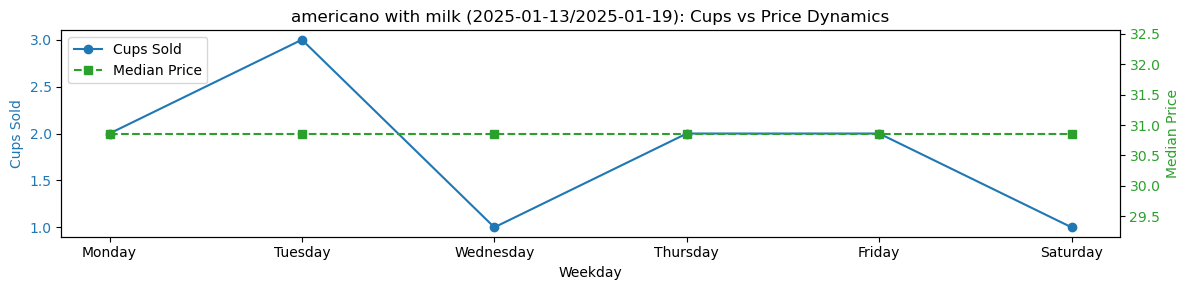

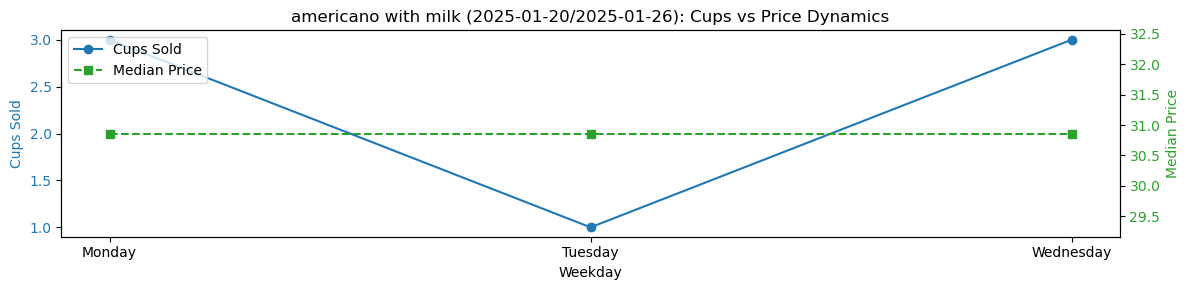

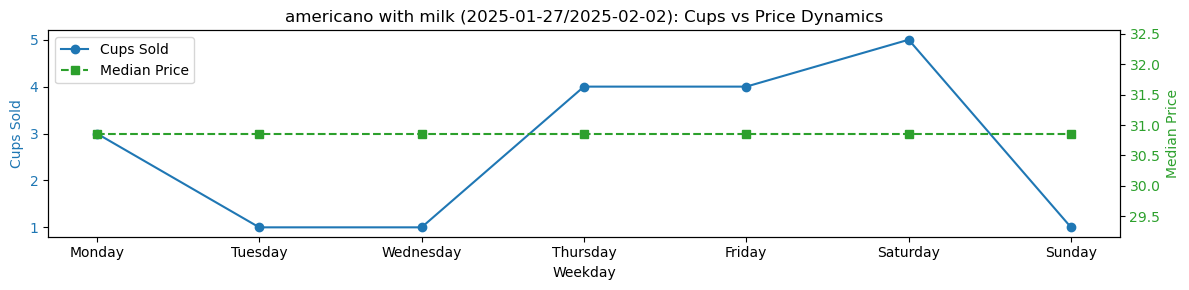

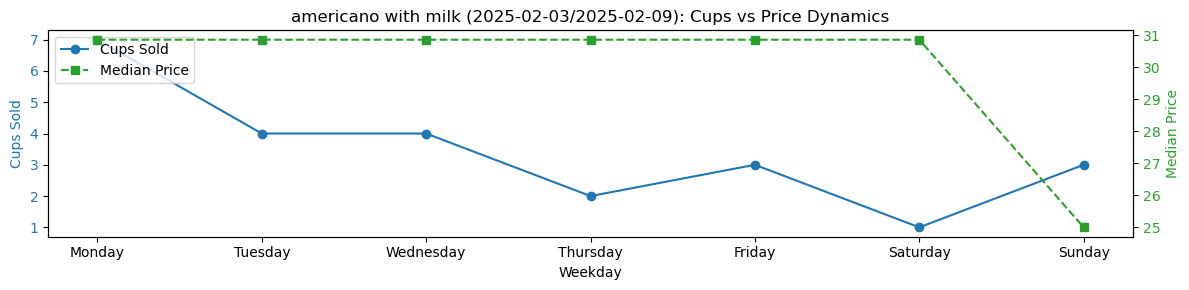

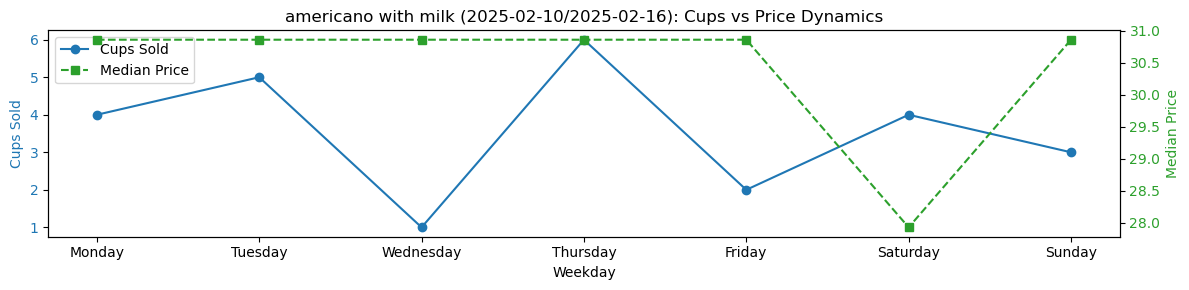

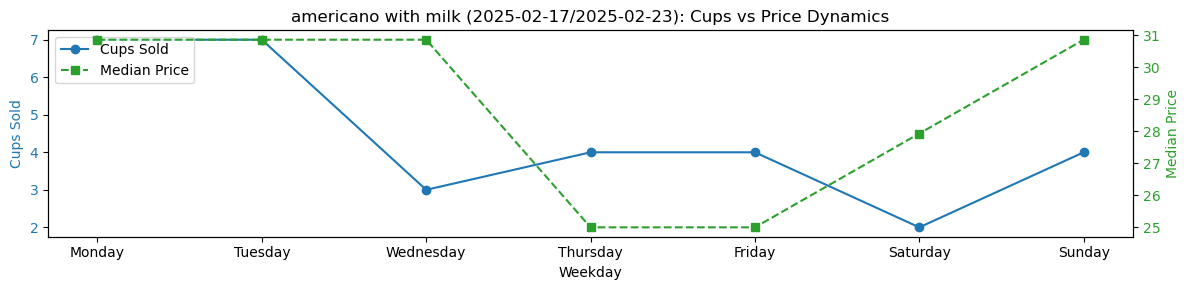

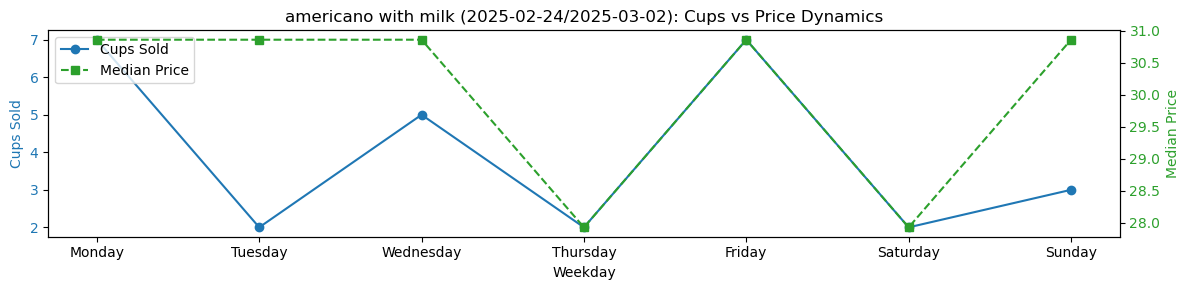

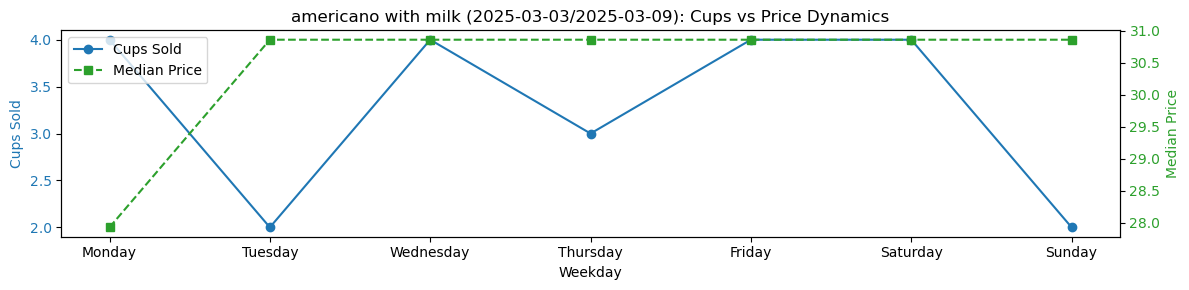

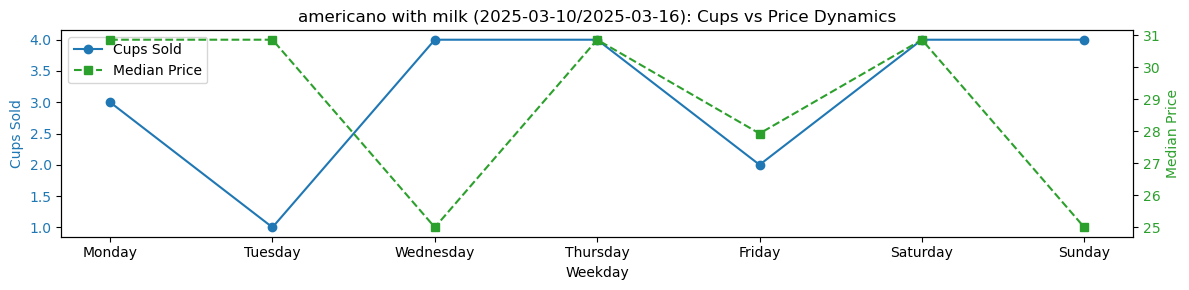

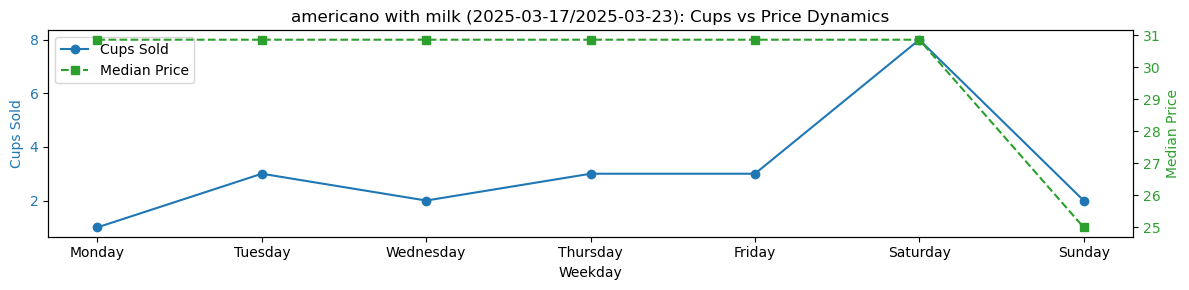

In [30]:
def weekly_cups_and_price_dynamics(df, coffee_name):
    df = df.copy()
    df['date'] = pandas.to_datetime(df['date'])
    df['week'] = df['date'].dt.to_period('W')
    df['weekday'] = df['date'].dt.day_name()
    
    # Filter for the specific coffee type
    df = df[df['coffee_name'] == coffee_name]
    
    # Group by week, weekday
    grouped = (
        df.groupby(['week','weekday'])
          .agg(cups=('money','count'),
               median_price=('money','median'))
          .reset_index()
    )
    
    # Ensure weekdays are ordered Mon–Sun
    weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    grouped['weekday'] = pandas.Categorical(grouped['weekday'], categories=weekday_order, ordered=True)
    
    # Identify weeks present
    weeks = grouped['week'].unique()
    print(f"{coffee_name}: {len(weeks)} weeks present -> {list(weeks)}")
    
    # Plot per week
    for week in weeks:
        df_week = grouped[grouped['week'] == week].sort_values('weekday')  # <-- sort here
        
        fig, ax1 = pyplot.subplots(figsize=(12,3))
        
        # Cups line
        ax1.plot(df_week['weekday'], df_week['cups'],
                 marker='o', linestyle='-', color='tab:blue', label='Cups Sold')
        ax1.set_xlabel("Weekday")
        ax1.set_ylabel("Cups Sold", color='tab:blue')
        ax1.tick_params(axis='y', labelcolor='tab:blue')
        
        # Price line on second axis
        ax2 = ax1.twinx()
        ax2.plot(df_week['weekday'], df_week['median_price'],
                 marker='s', linestyle='--', color='tab:green', label='Median Price')
        ax2.set_ylabel("Median Price", color='tab:green')
        ax2.tick_params(axis='y', labelcolor='tab:green')
        
        # Title
        pyplot.title(f"{coffee_name} ({week}): Cups vs Price Dynamics")
        
        # Combine legends
        lines, labels = [], []
        for axis in [ax1, ax2]:
            l, lab = axis.get_legend_handles_labels()
            lines += l
            labels += lab
        ax1.legend(lines, labels, loc='upper left')
        
        pyplot.tight_layout()
        pyplot.show()


weekly_cups_and_price_dynamics(data, coffee_name='americano with milk')

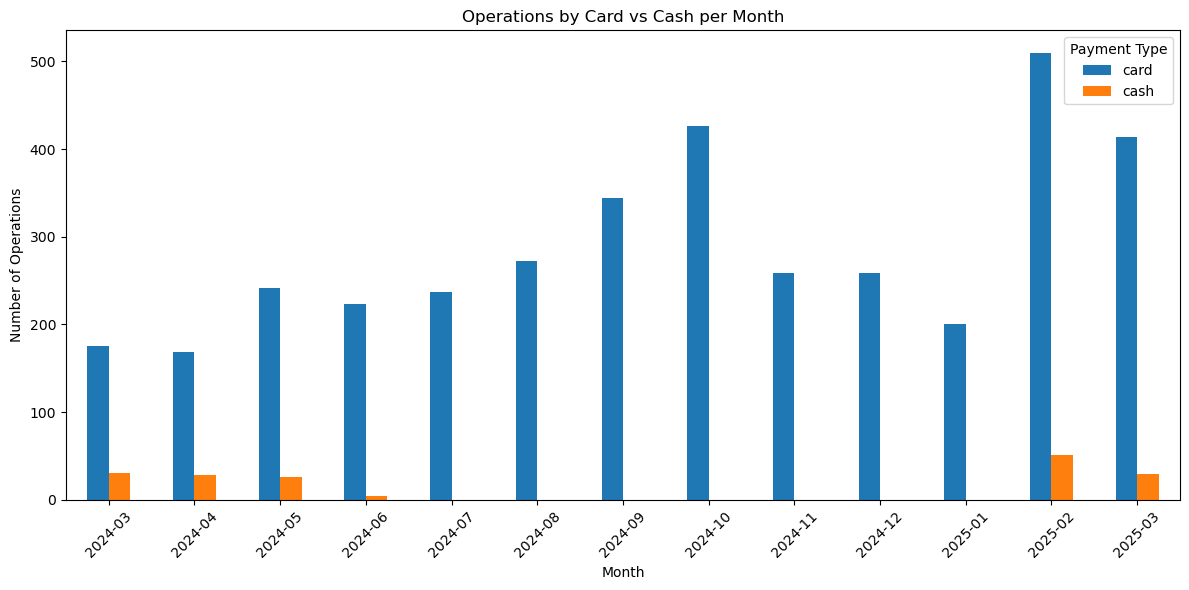

In [31]:
def monthly_card_cash_operations(df):
    df = df.copy()
    df['date'] = pandas.to_datetime(df['date'])
    df['month'] = df['date'].dt.to_period('M').astype(str)  # convert to string for plotting
    
    # Group by month and cash_type
    grouped = (
        df.groupby(['month','cash_type'])
          .size()
          .reset_index(name='operations')
    )
    
    # Pivot so we have columns for card and cash
    pivot = grouped.pivot(index='month', columns='cash_type', values='operations').fillna(0)
    
    # Plot grouped bar chart
    pivot.plot(kind='bar', figsize=(12,6), color=['tab:blue','tab:orange'])
    pyplot.title("Operations by Card vs Cash per Month")
    pyplot.xlabel("Month")
    pyplot.ylabel("Number of Operations")
    pyplot.xticks(rotation=45)
    pyplot.legend(title="Payment Type")
    pyplot.tight_layout()
    pyplot.show()

monthly_card_cash_operations(data)

In [32]:
print('card unique values: ' + str(len(data['card'].unique())))

data_card = data.copy()
    
counts = (
    data_card['card']
    .value_counts()
    .rename_axis('card')          # name the index column
    .reset_index(name='count')    # create a 'count' column
    .sort_values(by='count', ascending=False)
    .reset_index(drop=True)
)

# Calculate numerator: sum of counts > 1
sum_gt1 = (counts['count'] > 1).sum()
sum_total = len(counts['count'])
ratio = sum_gt1 / sum_total * 100
print("sum_gt1:", sum_gt1)
print("sum_total:", sum_total)
#print("sun_na:", data['card'].isna().sum())
print("Ratio %:", ratio)

html_table = counts.to_html()
display(HTML(f"<div style='overflow-x: auto; max-height:400px;'>{html_table}</div>"))

card unique values: 1317
sum_gt1: 545
sum_total: 1316
Ratio %: 41.413373860182375


,card,count
0,ANON-0000-0000-0012,129
1,ANON-0000-0000-0141,108
2,ANON-0000-0000-1163,77
3,ANON-0000-0000-0276,69
4,ANON-0000-0000-0009,67
5,ANON-0000-0000-0507,51
6,ANON-0000-0000-0040,50
7,ANON-0000-0000-0097,47
8,ANON-0000-0000-1110,33
9,ANON-0000-0000-1170,32


Percent of clients, who made purchases more than 5 months: 26.08695652173913


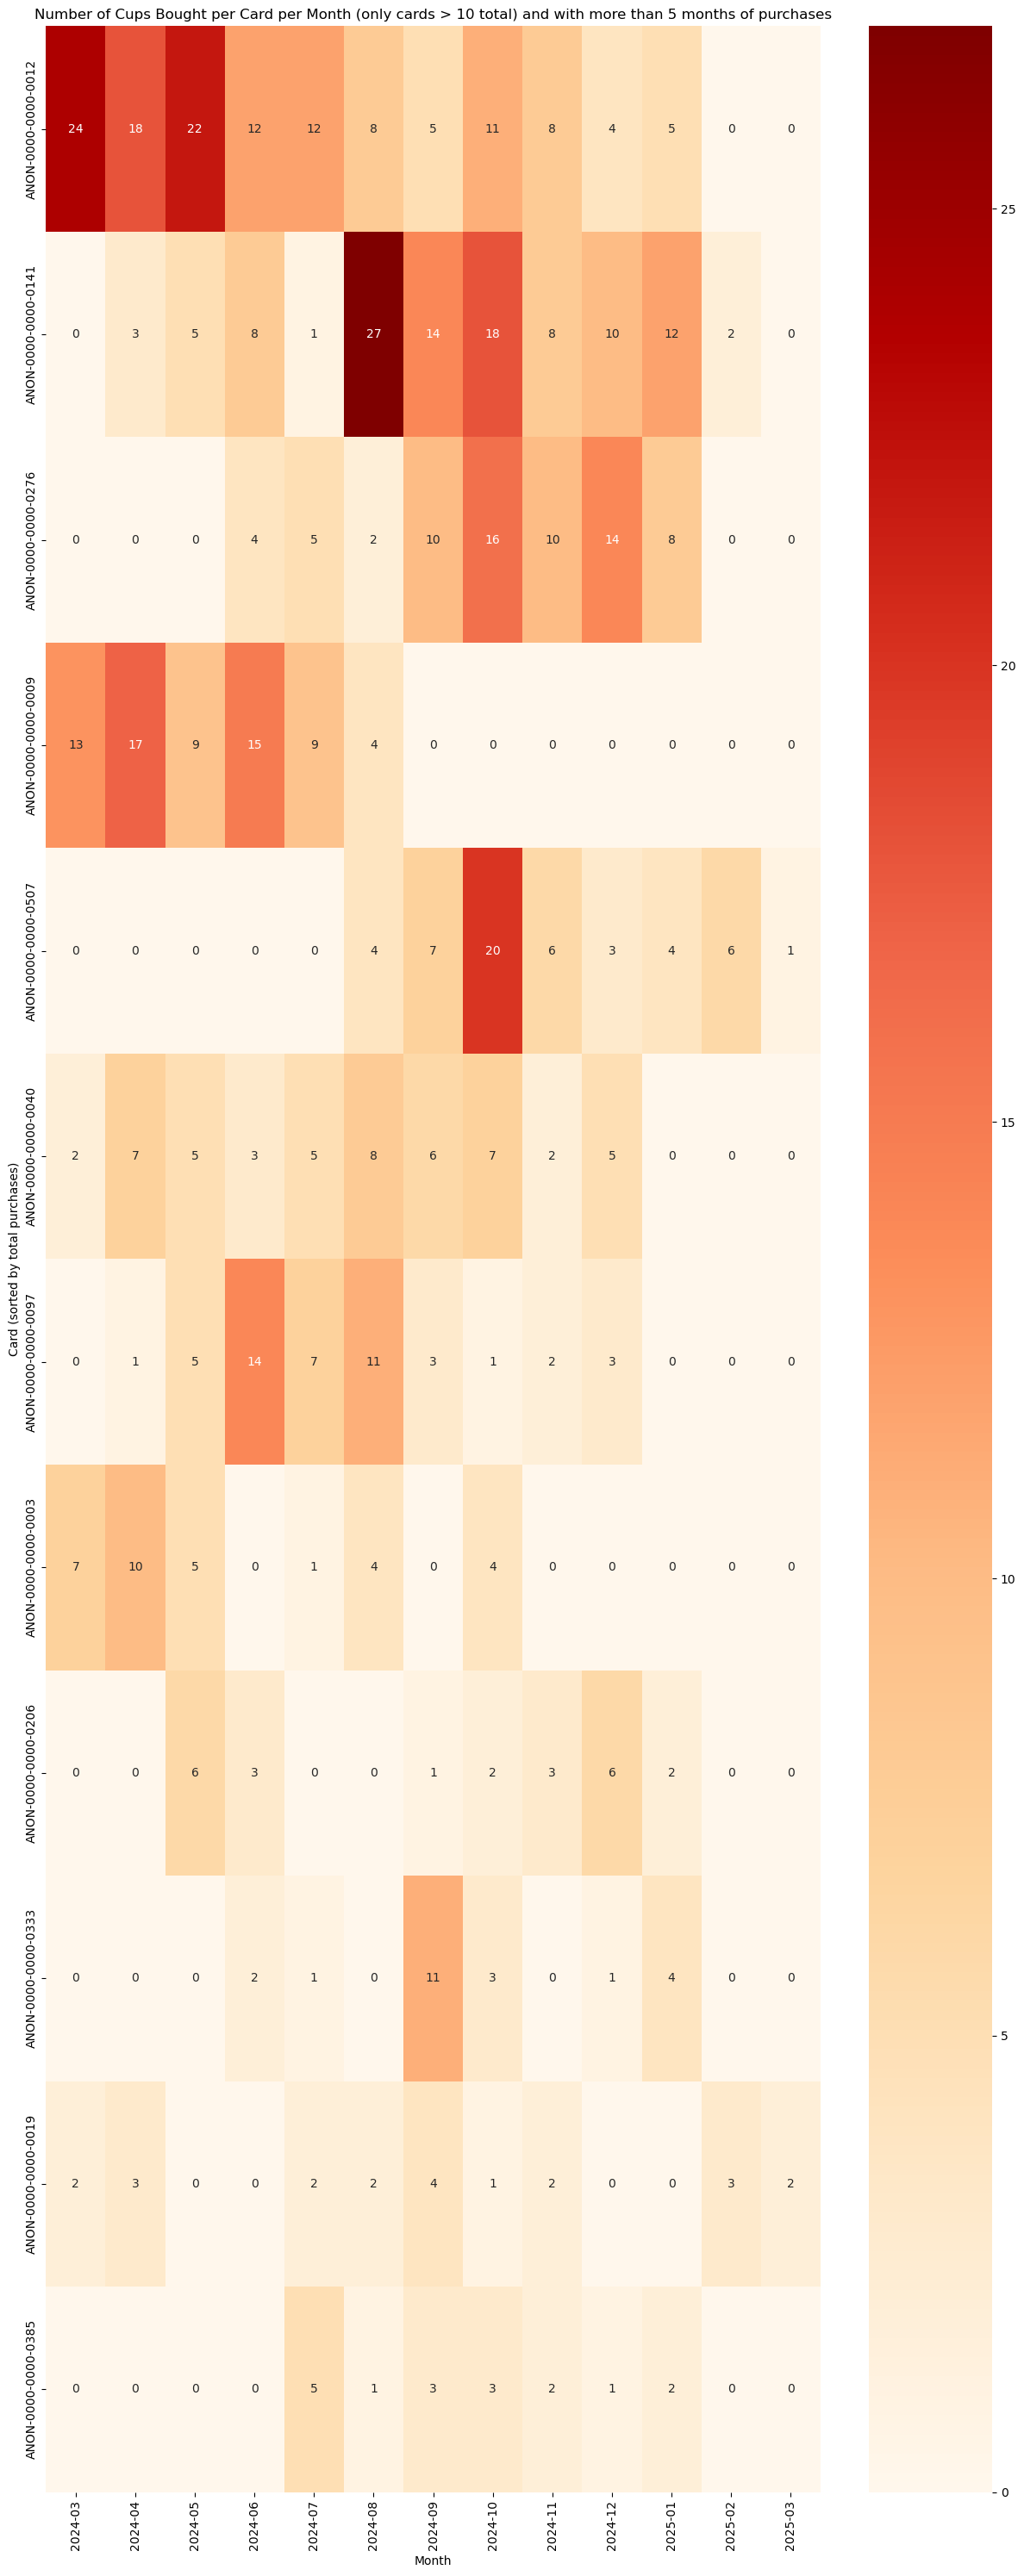

In [33]:
def card_monthly_heatmap(df, threshold=100):
    df = df.copy()
    df['date'] = pandas.to_datetime(df['date'])
    df['month'] = df['date'].dt.to_period('M').astype(str)
    
    # Group by card and month -> count cups
    grouped = (
        df.groupby(['card','month'])
          .size()
          .reset_index(name='cups')
    )
    
    # Total purchases per card
    totals = grouped.groupby('card')['cups'].sum()
    
    # Filter cards with total purchases > threshold
    valid_cards = totals[totals > threshold].sort_values(ascending=False)
    sorted_cards = valid_cards.index.tolist()
    
    # Pivot table: rows=card, cols=month, values=cups
    pivot = grouped.pivot(index='card', columns='month', values='cups').fillna(0)
    
    # Keep only valid cards and reorder
    pivot = pivot.loc[sorted_cards]

    return pivot

threshold = 10
pivot_card_month = card_monthly_heatmap(data, threshold)

def filter_cards_by_active_months(pivot, min_active_months):
    active_months = (pivot > 0).sum(axis=1)
    filtered_pivot = pivot.loc[active_months > min_active_months]
    
    return filtered_pivot

months_of_purchases = 5
frequent_card_pivot = filter_cards_by_active_months(pivot_card_month, months_of_purchases)
print(f"Percent of clients, who made purchases more than {months_of_purchases} months: {(len(frequent_card_pivot) / len(pivot_card_month) ) * 100}")

# Plot heatmap
pyplot.figure(figsize=(12,30))
seaborn.heatmap(frequent_card_pivot, cmap="OrRd", annot=True, fmt=".0f")
pyplot.title(f"Number of Cups Bought per Card per Month (only cards > {threshold} total) and with more than {months_of_purchases} months of purchases")
pyplot.xlabel("Month")
pyplot.ylabel("Card (sorted by total purchases)")
pyplot.tight_layout()
pyplot.show()

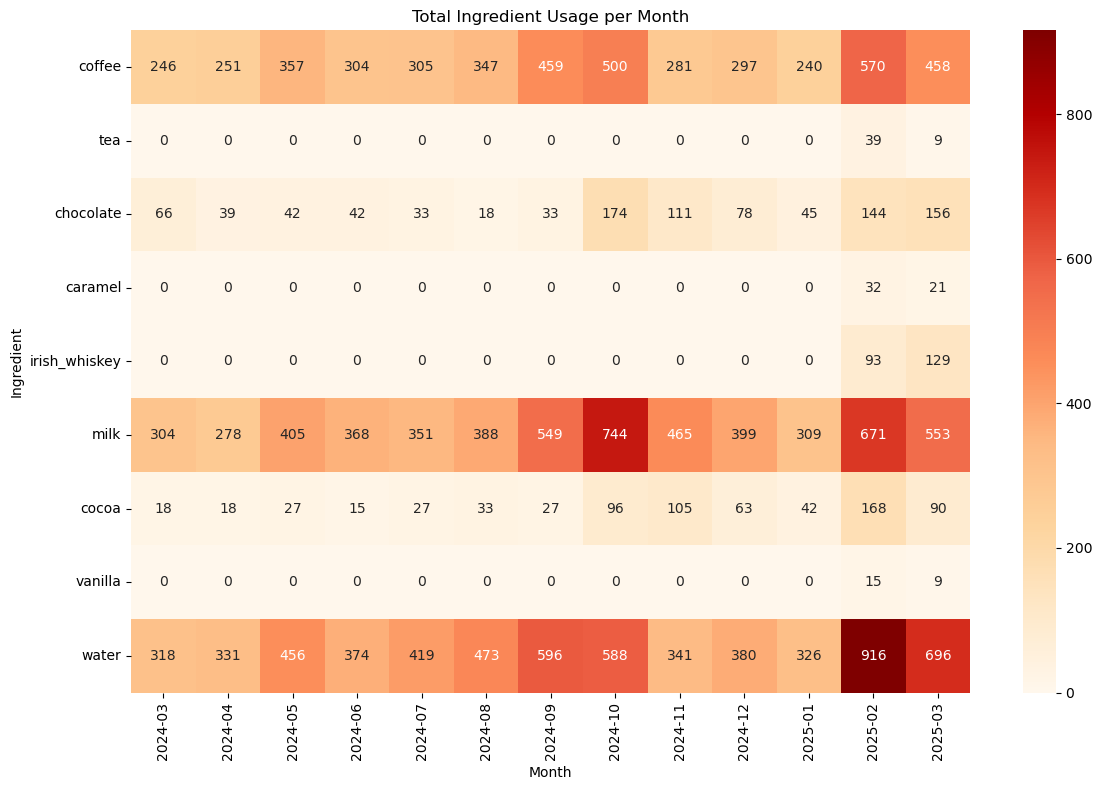

,coffee,tea,chocolate,caramel,irish_whiskey,milk,cocoa,vanilla,water
month,,,,,,,,,
2024-03,246.0,0.0,66.0,0.0,0.0,304.0,18.0,0.0,318.0
2024-04,251.0,0.0,39.0,0.0,0.0,278.0,18.0,0.0,331.0
2024-05,357.0,0.0,42.0,0.0,0.0,405.0,27.0,0.0,456.0
2024-06,304.0,0.0,42.0,0.0,0.0,368.0,15.0,0.0,374.0
2024-07,305.0,0.0,33.0,0.0,0.0,351.0,27.0,0.0,419.0
2024-08,347.0,0.0,18.0,0.0,0.0,388.0,33.0,0.0,473.0
2024-09,459.0,0.0,33.0,0.0,0.0,549.0,27.0,0.0,596.0
2024-10,500.0,0.0,174.0,0.0,0.0,744.0,96.0,0.0,588.0
2024-11,281.0,0.0,111.0,0.0,0.0,465.0,105.0,0.0,341.0


In [36]:
def monthly_ingredient_heatmap(df):
    df = df.copy()
    df['date'] = pandas.to_datetime(df['date'])
    df['month'] = df['date'].dt.to_period('M').astype(str)

    ingredients = ['coffee','tea','chocolate','caramel','irish_whiskey',
                   'milk','cocoa','vanilla','water']

    # Group by month and sum ingredient usage
    monthly_totals = df.groupby('month')[ingredients].sum()

    # Plot heatmap
    pyplot.figure(figsize=(12,8))
    seaborn.heatmap(monthly_totals.T, cmap="OrRd", annot=True, fmt=".0f")
    pyplot.title("Total Ingredient Usage per Month")
    pyplot.xlabel("Month")
    pyplot.ylabel("Ingredient")
    pyplot.tight_layout()
    pyplot.show()

    return monthly_totals

monthly_ingredient_heatmap(data)

Итоги:
- чаще всего покупают (descending):
    - americano with milk
    - latte
    - americano
    - cappucino
- немного реже покупают (descending):
    - cortado
    - hot chocolate
    - cocoa
    - espresso
- c 2025-02-03 в автомате пояились новые позиции:
    - caramel
    - caramel coffee
    - caramel with chocolate
    - caramel with irish whiskey
    - caramel with milk
    - chocolate
    - chocolate with coffee
    - chocolate with milk
    - coffee with chocolate
    - coffee with irish whiskey
    - double chocolate
    - double espresso
    - double espresso with milk
    - double irish whiskey
    - double vanilla
    - irish whiskey
    - irish whiskey with milk
    - irish with chocolate
    - mochaccino
    - super chocolate
    - tea
    - vanilla coffee
    - vanilla with irish whiskey
- предположительно c 2025-03-03 в автомате пояились новые позиции:
    - double ristretto
    - hot milkshake
- из новых позиций топ-5:
    - irish whiskey
    - coffee with irish whiskey
    - tea
    - irish whiskey with milk
    - double irish whiskey
- в феврале 2025 введение новых напитков не снизило потребление топ-8 позиций, в марте 2025 есть снижение, но не факт, что это связано с новыми позициями (их объем продаж не так уж и велик)
- временнАя медиана совершения покупок - 14:30, а самая раннее время - 09:20, поэтому автомат стоит заправлять утром до 09:00
- по прибыльности топ-8 напитков совпадают с топ-8 по количеству, но порядок другой (это обусловлено отличием цен):
    - latte                   28658.30
    - americano with milk     26369.12
    - cappuccino              18514.14
    - americano               15437.26
    - hot chocolate           10172.46
    - cocoa                    8678.16
    - cortado                  7534.86
    - espresso                 3187.28
- цены были снижены на период май-июнь, вторая итерация снижения цен была на период июль-сентябрь, после чего цены подняли и не опускали. Введение новых продуктов не повлияло на изменение цены
- обзор графиков по типам кофе с 3 линиями
- обзор графиков по типам кофе с 2 линиями (ценой и количеством выпитых чашек)
- оплата производится в основном по карте, редко наличкой
- графики по уникальным картам